In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta
from collections import Counter

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor, NearestNeighbors
from sklearn.cluster import DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

from scipy.stats import mannwhitneyu

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_DATA_DIR = PROJECT_ROOT / 'data' / 'raw'
PROCESSED_DATA_DIR = PROJECT_ROOT / 'data' / 'processed'
RAW_DATA_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

## 1. Генерация синтетических тестовых данных

In [2]:
# Конфигурация генерации под локальный ПК (у меня не тянет файл 4гб, нужно много оперативки)
SYNTHETIC_TARGET_COMPANIES = 10_000
SYNTHETIC_SCALE = SYNTHETIC_TARGET_COMPANIES / 230_756
SYNTHETIC_CHUNK_SIZE = min(1_500, SYNTHETIC_TARGET_COMPANIES)

print(
    f"Синтетика будет сгенерирована пропорционально реальному профилю: "
    f"{SYNTHETIC_TARGET_COMPANIES:,} компаний x 27 snapshot = "
    f"{SYNTHETIC_TARGET_COMPANIES * 27:,} строк"
)
print(f"SYNTHETIC_SCALE = {SYNTHETIC_SCALE:.6f}; CHUNK_SIZE = {SYNTHETIC_CHUNK_SIZE:,}")

Синтетика будет сгенерирована пропорционально реальному профилю: 10,000 компаний x 27 snapshot = 270,000 строк
SYNTHETIC_SCALE = 0.043336; CHUNK_SIZE = 1,500


In [3]:
import os
from pathlib import Path

rng = np.random.default_rng(42)

REAL_PROFILE = {
    'n_companies': 230756,
    'n_snapshots': 27,
    'companies_with_finance': 30308,
    'companies_with_finance_last': 29001,
    'companies_with_expo_calc_last': 28122,
    'companies_with_limit_last': 18570,
    'companies_with_debt_last': 18405,
    'companies_with_positive_debt_any': 11626,
    'companies_with_positive_debt_last': 7154,
    'companies_with_restruct_last': 6873,
    'companies_with_last_restruct_dt': 1258,
    'companies_with_ovr_cnt_last': 1658,
    'companies_with_claim_count': 130466,
    'companies_with_claim_sum': 110000,
    'companies_high_claims': 19490,
    'companies_jump_observed': 95000,
    'companies_jump_trigger': 46440,
    'companies_registry': 2767,
    'companies_susp_flag': 615,
    'companies_default_current': 3973,
    'companies_default_historical_only': 411,
    'companies_zero_debt_anomaly': 14672,
    'companies_expo_debt_mismatch': 9270,
    'companies_reserv_expo_anomaly': 741,
    'companies_overdue_signal': 4551,
    'companies_restruct_ge2': 866,
    'companies_bankruptcy_status': 4300,
    'companies_case_end_dt': 2500,
    'companies_fraud_gt': 17879,
    'missingness': {
        'util_limit_amt': 100.00,
        'last_restruct_dt': 99.98,
        'frd_start_dt': 99.95,
        'frdsgn_imp_on_dflt_flag': 99.95,
        'default_end_dt': 99.92,
        'frd_susp_flag': 99.74,
        'frd_stg_name': 99.50,
        'ovr_cnt': 99.29,
        'frd_rgstr_sid': 99.18,
        'frd_check_end_dt': 99.18,
        'frdsgn_stts_code': 99.18,
        'frd_scheme_code': 99.18,
        'frd_src_code': 99.18,
        'case_end_dt': 98.93,
        'restruct_cnt': 98.87,
        'default_start_dt': 98.72,
        'b_claim_status': 98.15,
        'limit_amt': 96.57,
        'issue_dt': 96.19,
        'debt_ovr_rub': 94.80,
        'debt_due_rub': 94.80,
        'doc_number': 94.55,
        'agr_regls_type_codes': 94.55,
        'signed_dt': 94.55,
        'expiration_dt': 94.55,
        'grntee_prod_name': 94.55,
        'overdue_od_calc': 92.56,
        'reserv_prud_calc': 92.56,
        'expo_calc': 92.56,
        'od_calc': 92.56,
    },
}

GENERATION_SCALE = float(globals().get('SYNTHETIC_SCALE', os.environ.get('SYNTHETIC_SCALE', '1.0')))
CHUNK_SIZE = int(globals().get('SYNTHETIC_CHUNK_SIZE', os.environ.get('SYNTHETIC_CHUNK_SIZE', '4000')))
N_COMPANIES = max(1000, int(round(REAL_PROFILE['n_companies'] * GENERATION_SCALE)))
snapshot_dates = pd.date_range('2024-01-31', periods=REAL_PROFILE['n_snapshots'], freq='ME')
N_SNAPSHOTS = len(snapshot_dates)
OUTPUT_PATH = RAW_DATA_DIR / 'test_data.csv'
GT_PATH = RAW_DATA_DIR / 'test_gt.csv'

OKVED_NAMES = {
    'A': 'Сельское хозяйство',
    'B': 'Добыча полезных ископаемых',
    'C': 'Обрабатывающие производства',
    'D': 'Электроэнергия',
    'E': 'Водоснабжение',
    'F': 'Строительство',
    'G': 'Торговля',
    'H': 'Транспортировка и хранение',
    'I': 'Гостиницы и общественное питание',
    'J': 'Информация и связь',
    'K': 'Финансовая деятельность',
    'L': 'Операции с недвижимостью',
    'M': 'Научная и техническая деятельность',
    'N': 'Административная деятельность',
    'O': 'Госуправление',
    'P': 'Образование',
    'Q': 'Здравоохранение',
    'R': 'Культура и спорт',
    'S': 'Прочие услуги',
}

ORG_SECTOR_BY_OKVED = {
    'A': 'АПК',
    'B': 'Добыча и сырьё',
    'C': 'Промышленность',
    'D': 'Энергетика',
    'E': 'Инфраструктура',
    'F': 'Строительство',
    'G': 'Торговля',
    'H': 'Транспорт и логистика',
    'I': 'HoReCa',
    'J': 'IT и связь',
    'K': 'Финансы',
    'L': 'Недвижимость',
    'M': 'Профессиональные услуги',
    'N': 'Сервисы',
    'O': 'Госсектор',
    'P': 'Образование',
    'Q': 'Медицина',
    'R': 'Культура и спорт',
    'S': 'Прочие услуги',
}

SEGMENT_MULTIPLIER = {
    'Крупнейшие': 5.4,
    'Крупные': 3.8,
    'Средние': 1.9,
    'Малые': 0.85,
    'Микро': 0.35,
    'Клиенты машиностроения': 1.6,
    'Рег. госсектор': 2.6,
    'Фин.институты': 3.2,
}

RISK_SEGMENT_VALUES = [
    'Корпоративная компания-резидент (РФ)',
    'Корп. компания-резидент (РФ)',
    'Контрактное финансирование (прочее кредитование)',
    'Кредитование корпоративных клиентов',
    'Региональный госсектор',
    'Лизинговая компания',
]

TERBANK_REGION_POOL = {
    'Центральный аппарат': ['москва', 'московская область'],
    'Уральский банк': ['свердловская область', 'челябинская область', 'тюменская область'],
    'Среднерусский банк': ['московская область', 'тульская область', 'калужская область', 'смоленская область'],
    'Центрально-Черноземный банк': ['воронежская область', 'курская область', 'белгородская область', 'липецкая область'],
    'Московский банк': ['москва', 'московская область'],
    'Волго-Вятский банк': ['нижегородская область', 'татарстан', 'чувашия', 'кировская область'],
    'Байкальский банк': ['иркутская область', 'бурятия', 'забайкальский край'],
    'Юго-Западный банк': ['краснодарский край', 'ростовская область', 'ставропольский край'],
    'Сибирский банк': ['новосибирская область', 'красноярский край', 'томская область', 'омская область'],
    'Поволжский банк': ['самарская область', 'ульяновская область', 'саратовская область'],
    'Дальневосточный банк': ['приморский край', 'хабаровский край', 'амурская область'],
    'Северо-Западный банк': ['санкт-петербург', 'ленинградская область', 'калининградская область'],
}
ALL_REGIONS = sorted({region for regions in TERBANK_REGION_POOL.values() for region in regions} | {
    'республика башкортостан', 'республика саха (якутия)', 'оренбургская область', 'архангельская область'
})

ALL_COLUMNS = [
    'org_id', 'snapshot_date', 'start_dt_ckp', 'end_dt_ckp', 'fact_address', 'inn',
    'okved_cd', 'okved_name', 'okved_section', 'terbank', 'org_sector', 'liquidation',
    'okk_code', 'risk_segment', 'gsz_name', 'reg_region', 'reg_region_norm',
    'frd_terbank_reg_match', 'segment_name', 'frd_segment_changed_1y',
    'frd_segment_changed_2y', 'frd_reject_diff_segment_2y', 'last_restruct_dt',
    'claim_sum', 'claim_date', 'b_claim_status', 'claim_num', 'case_end_dt',
    'wasbankrupt', 'm_claim_sum', 'claim_count', 'jump_year', 'frd_jump_score',
    'max_growth_pct', 'prev_revenue', 'jump_revenue', 'max_growth_rub',
    'frd_scheme_code', 'frd_rgstr_sid', 'frdsgn_stts_code', 'frd_stg_name',
    'frd_src_code', 'frd_start_dt', 'frdsgn_imp_on_dflt_flag', 'frd_check_end_dt',
    'frd_susp_flag', 'inn_benef_0', 'benef_ip_0', 'okved_cd_benef_0',
    'okved_name_benef_ip_0', 'okved_section_benef_0', 'frd_liquidation_ben_0',
    'inn_benef_1', 'benef_ip_1', 'okved_cd_benef_1', 'okved_name_benef_ip_1',
    'okved_section_benef_1', 'liquidation_ben_1', 'ben_0', 'ben_1', 'ben_3', 'ben_5',
    'frd_ben_0_changed', 'epk_owner', 'epk_director', 'frd_owner_changed_1y',
    'doc_number', 'signed_dt', 'expiration_dt', 'issue_dt', 'agr_regls_type_codes',
    'grntee_prod_name', 'debt_due_rub', 'debt_ovr_rub', 'util_limit_amt',
    'exposure_amt', 'limit_amt', 'restruct_cnt', 'problem_group', 'ovr_cnt',
    'default_start_dt', 'default_end_dt', 'expo_calc', 'reserv_prud_calc',
    'reserv_ocen_calc', 'od_calc', 'due_od_calc', 'overdue_od_calc',
    'frd_okved_section_diff_benef_0', 'frd_okved_section_diff_benef_1',
    'frd_okved_cd_diff_benef_0', 'frd_okved_cd_diff_benef_1',
]

DATE_COLUMNS = {
    'snapshot_date', 'start_dt_ckp', 'end_dt_ckp', 'last_restruct_dt', 'claim_date',
    'case_end_dt', 'wasbankrupt', 'frd_start_dt', 'frd_check_end_dt', 'signed_dt',
    'expiration_dt', 'issue_dt', 'default_start_dt', 'default_end_dt'
}

NUMERIC_NULL_COLUMNS = {
    'claim_sum', 'm_claim_sum', 'claim_count', 'jump_year', 'frd_jump_score',
    'max_growth_pct', 'prev_revenue', 'jump_revenue', 'max_growth_rub', 'frd_rgstr_sid',
    'frdsgn_imp_on_dflt_flag', 'frd_susp_flag', 'ben_0', 'ben_1', 'ben_3', 'ben_5',
    'frd_ben_0_changed', 'epk_owner', 'epk_director', 'frd_owner_changed_1y',
    'debt_due_rub', 'debt_ovr_rub', 'util_limit_amt', 'exposure_amt', 'limit_amt',
    'restruct_cnt', 'ovr_cnt', 'expo_calc', 'reserv_prud_calc', 'reserv_ocen_calc',
    'od_calc', 'due_od_calc', 'overdue_od_calc', 'frd_okved_section_diff_benef_0',
    'frd_okved_section_diff_benef_1', 'frd_okved_cd_diff_benef_0', 'frd_okved_cd_diff_benef_1'
}


def scaled_count(value):
    if value == 0:
        return 0
    scaled = int(round(value * GENERATION_SCALE))
    return min(N_COMPANIES, max(1, scaled))


def scale_distribution(counts, total):
    series = pd.Series(counts, dtype=float)
    raw = series / series.sum() * total
    base = np.floor(raw).astype(int)
    remainder = total - int(base.sum())
    if remainder > 0:
        order = (raw - base).sort_values(ascending=False).index.tolist()
        for key in order[:remainder]:
            base[key] += 1
    elif remainder < 0:
        order = (raw - base).sort_values().index.tolist()
        for key in order:
            if remainder == 0:
                break
            if base[key] > 0:
                base[key] -= 1
                remainder += 1
    return base.to_dict()


def expand_distribution(counts):
    values = []
    for key, count in counts.items():
        values.extend([key] * int(count))
    arr = np.array(values, dtype=object)
    if len(arr) != N_COMPANIES:
        raise ValueError(f'Размер распределения {len(arr)} != {N_COMPANIES}')
    rng.shuffle(arr)
    return arr


def pick_mask(count, priority, allowed_mask=None):
    if allowed_mask is None:
        allowed_mask = np.ones(N_COMPANIES, dtype=bool)
    allowed_idx = np.flatnonzero(allowed_mask)
    count = int(min(max(count, 0), len(allowed_idx)))
    result = np.zeros(N_COMPANIES, dtype=bool)
    if count == 0:
        return result
    score = priority[allowed_mask] + rng.normal(0, 1e-6, len(allowed_idx))
    top_local = np.argpartition(score, -count)[-count:]
    result[allowed_idx[top_local]] = True
    return result


def assign_lengths(active_mask, low, high, strength):
    lengths = np.zeros(N_COMPANIES, dtype=int)
    idx = np.flatnonzero(active_mask)
    if len(idx) == 0:
        return lengths
    local = strength[idx]
    local = (local - local.min()) / (local.max() - local.min() + 1e-9)
    lengths[idx] = np.clip(np.round(low + local * (high - low) + rng.normal(0, 1.6, len(idx))), low, high).astype(int)
    return lengths


def assign_starts(lengths, include_last_mask):
    starts = np.full(N_COMPANIES, -1, dtype=int)
    active_idx = np.flatnonzero(lengths > 0)
    if len(active_idx) == 0:
        return starts
    starts[include_last_mask] = N_SNAPSHOTS - lengths[include_last_mask]
    hist_idx = active_idx[~include_last_mask[active_idx]]
    for idx in hist_idx:
        high = max(1, N_SNAPSHOTS - lengths[idx])
        starts[idx] = int(rng.integers(0, high))
    return starts


def mask_from_window(start, length):
    mask = np.zeros(N_SNAPSHOTS, dtype=bool)
    if length <= 0 or start < 0:
        return mask
    stop = min(N_SNAPSHOTS, start + length)
    mask[start:stop] = True
    return mask


OKVED_COUNTS = {
    'A': 7639,
    'B': 2804,
    'C': 24207,
    'D': 4278,
    'E': 4334,
    'F': 23711,
    'G': 49067,
    'H': 10424,
    'I': 6009,
    'J': 7954,
    'K': 8769,
    'L': 23625,
    'M': 25101,
    'N': 5547,
    'O': 6200,
    'P': 5800,
    'Q': 3905,
    'R': 5600,
    'S': 5782,
}
SEGMENT_COUNTS = {
    'Крупнейшие': 10632,
    'Крупные': 15798,
    'Малые': 20558,
    'Средние': 124260,
    'Микро': 3285,
    'Клиенты машиностроения': 4008,
    'Рег. госсектор': 52180,
    'Фин.институты': 35,
}
TERBANK_COUNTS = {
    'Центральный аппарат': 2746,
    'Уральский банк': 20069,
    'Среднерусский банк': 26038,
    'Центрально-Черноземный банк': 11771,
    'Московский банк': 38654,
    'Волго-Вятский банк': 21337,
    'Байкальский банк': 6980,
    'Юго-Западный банк': 26980,
    'Сибирский банк': 16683,
    'Поволжский банк': 15679,
    'Дальневосточный банк': 11557,
    'Северо-Западный банк': 32262,
}
PROBLEM_GROUP_COUNTS = {
    None: 128660,
    'Green Zone': 59282,
    'Watchlist': 23591,
    'Yellow Zone': 243,
    'Red Zone': 1838,
    'Black Zone': 17142,
}

okved_section = expand_distribution(scale_distribution(OKVED_COUNTS, N_COMPANIES))
segment_name = expand_distribution(scale_distribution(SEGMENT_COUNTS, N_COMPANIES))
terbank = expand_distribution(scale_distribution(TERBANK_COUNTS, N_COMPANIES))
problem_group = expand_distribution(scale_distribution(PROBLEM_GROUP_COUNTS, N_COMPANIES))
problem_group_ordinal = pd.Series(problem_group).map({
    'Green Zone': 0,
    'Watchlist': 1,
    'Yellow Zone': 2,
    'Red Zone': 3,
    'Black Zone': 4,
}).fillna(-1).to_numpy()

latent_risk = (
    rng.normal(0, 1, N_COMPANIES)
    + np.clip(problem_group_ordinal, 0, None) * 0.8
    + pd.Series(segment_name).map({'Крупнейшие': 0.45, 'Крупные': 0.30, 'Средние': 0.10, 'Малые': 0.05}).fillna(0).to_numpy()
    + pd.Series(okved_section).map({'A': 0.30, 'C': 0.25, 'H': 0.15, 'G': 0.12, 'F': 0.10}).fillna(0).to_numpy()
)

jump_observed = pick_mask(scaled_count(REAL_PROFILE['companies_jump_observed']), latent_risk + rng.normal(0, 0.25, N_COMPANIES))
jump_trigger = pick_mask(scaled_count(REAL_PROFILE['companies_jump_trigger']), latent_risk + rng.normal(0, 0.25, N_COMPANIES), allowed_mask=jump_observed)
frd_segment_changed_2y = pick_mask(scaled_count(66353), latent_risk + rng.normal(0, 0.30, N_COMPANIES))
frd_segment_changed_1y = pick_mask(scaled_count(31547), latent_risk + frd_segment_changed_2y * 0.6 + rng.normal(0, 0.30, N_COMPANIES))
frd_reject_diff_segment_2y = pick_mask(scaled_count(2305), latent_risk + frd_segment_changed_2y * 1.1 + rng.normal(0, 0.20, N_COMPANIES))
frd_ben_0_changed = pick_mask(scaled_count(71559), latent_risk + rng.normal(0, 0.35, N_COMPANIES))
frd_owner_changed_1y = pick_mask(scaled_count(947), latent_risk + frd_segment_changed_2y * 0.8 + rng.normal(0, 0.10, N_COMPANIES))

ben_present = pick_mask(scaled_count(198075), latent_risk + rng.normal(0, 0.25, N_COMPANIES))
frd_okved_section_diff_benef_0 = pick_mask(scaled_count(11416), latent_risk + rng.normal(0, 0.25, N_COMPANIES), allowed_mask=ben_present)
frd_okved_section_diff_benef_1 = pick_mask(scaled_count(21624), latent_risk + rng.normal(0, 0.25, N_COMPANIES), allowed_mask=ben_present)
frd_okved_cd_diff_benef_0 = frd_okved_section_diff_benef_0.copy()
frd_okved_cd_diff_benef_1 = frd_okved_section_diff_benef_1.copy()

claim_count_any = pick_mask(scaled_count(REAL_PROFILE['companies_with_claim_count']), latent_risk + rng.normal(0, 0.35, N_COMPANIES))
claim_sum_any = pick_mask(scaled_count(REAL_PROFILE['companies_with_claim_sum']), latent_risk + claim_count_any * 0.55 + rng.normal(0, 0.25, N_COMPANIES), allowed_mask=claim_count_any)
high_claims = pick_mask(scaled_count(REAL_PROFILE['companies_high_claims']), latent_risk + claim_sum_any * 0.8 + rng.normal(0, 0.15, N_COMPANIES), allowed_mask=claim_sum_any)

registry_flag = pick_mask(scaled_count(REAL_PROFILE['companies_registry']), latent_risk + high_claims * 0.9 + rng.normal(0, 0.10, N_COMPANIES))
frd_susp_companies = pick_mask(scaled_count(REAL_PROFILE['companies_susp_flag']), latent_risk + registry_flag * 1.2 + rng.normal(0, 0.10, N_COMPANIES), allowed_mask=registry_flag)
default_current = pick_mask(scaled_count(REAL_PROFILE['companies_default_current']), latent_risk + registry_flag * 0.8 + high_claims * 0.6 + rng.normal(0, 0.15, N_COMPANIES))
default_hist_only = pick_mask(scaled_count(REAL_PROFILE['companies_default_historical_only']), latent_risk + high_claims * 0.4 + rng.normal(0, 0.15, N_COMPANIES), allowed_mask=~default_current)
finance_any = pick_mask(
    scaled_count(REAL_PROFILE['companies_with_finance']),
    latent_risk + claim_sum_any * 0.7 + default_current * 1.0 + registry_flag * 0.8 + rng.normal(0, 0.25, N_COMPANIES),
)
finance_last = pick_mask(
    scaled_count(REAL_PROFILE['companies_with_finance_last']),
    latent_risk + claim_sum_any * 0.5 + default_current * 0.8 + rng.normal(0, 0.20, N_COMPANIES),
    allowed_mask=finance_any,
)
finance_hist_only = finance_any & ~finance_last
expo_calc_last = pick_mask(scaled_count(REAL_PROFILE['companies_with_expo_calc_last']), latent_risk + rng.normal(0, 0.20, N_COMPANIES), allowed_mask=finance_last)
limit_last = pick_mask(scaled_count(REAL_PROFILE['companies_with_limit_last']), latent_risk + rng.normal(0, 0.20, N_COMPANIES), allowed_mask=finance_last)
debt_last = pick_mask(scaled_count(REAL_PROFILE['companies_with_debt_last']), latent_risk + default_current * 0.5 + rng.normal(0, 0.20, N_COMPANIES), allowed_mask=finance_last)
positive_debt_any = pick_mask(scaled_count(REAL_PROFILE['companies_with_positive_debt_any']), latent_risk + default_current * 0.7 + registry_flag * 0.5 + rng.normal(0, 0.20, N_COMPANIES), allowed_mask=finance_any)
positive_debt_last = pick_mask(scaled_count(REAL_PROFILE['companies_with_positive_debt_last']), latent_risk + default_current * 0.9 + rng.normal(0, 0.15, N_COMPANIES), allowed_mask=positive_debt_any & debt_last)
positive_debt_hist_only = positive_debt_any & ~positive_debt_last
restruct_last = pick_mask(scaled_count(REAL_PROFILE['companies_with_restruct_last']), latent_risk + default_current * 0.4 + rng.normal(0, 0.20, N_COMPANIES), allowed_mask=finance_last)
restruct_ge2 = pick_mask(scaled_count(REAL_PROFILE['companies_restruct_ge2']), latent_risk + default_current * 0.9 + rng.normal(0, 0.10, N_COMPANIES), allowed_mask=restruct_last)
last_restruct_seen = pick_mask(scaled_count(REAL_PROFILE['companies_with_last_restruct_dt']), latent_risk + default_current * 0.8 + rng.normal(0, 0.10, N_COMPANIES), allowed_mask=restruct_last)
ovr_cnt_last = pick_mask(scaled_count(REAL_PROFILE['companies_with_ovr_cnt_last']), latent_risk + default_current * 0.9 + rng.normal(0, 0.10, N_COMPANIES), allowed_mask=debt_last)
overdue_signal = pick_mask(scaled_count(REAL_PROFILE['companies_overdue_signal']), latent_risk + default_current * 0.8 + rng.normal(0, 0.15, N_COMPANIES), allowed_mask=finance_any)
reserv_expo_anomaly = pick_mask(scaled_count(REAL_PROFILE['companies_reserv_expo_anomaly']), latent_risk + default_current * 1.1 + rng.normal(0, 0.10, N_COMPANIES), allowed_mask=expo_calc_last)
zero_debt_allowed = finance_last & (claim_sum_any | default_current) & ~positive_debt_last
zero_debt_anomaly = pick_mask(scaled_count(REAL_PROFILE['companies_zero_debt_anomaly']), latent_risk + claim_sum_any * 0.6 + default_current * 1.1 + rng.normal(0, 0.15, N_COMPANIES), allowed_mask=zero_debt_allowed)
expo_debt_mismatch = pick_mask(scaled_count(REAL_PROFILE['companies_expo_debt_mismatch']), latent_risk + zero_debt_anomaly * 0.8 + rng.normal(0, 0.15, N_COMPANIES), allowed_mask=expo_calc_last & ~positive_debt_last)
bankruptcy_status = pick_mask(scaled_count(REAL_PROFILE['companies_bankruptcy_status']), latent_risk + claim_sum_any * 0.7 + rng.normal(0, 0.15, N_COMPANIES), allowed_mask=claim_sum_any)
case_end_companies = pick_mask(scaled_count(REAL_PROFILE['companies_case_end_dt']), latent_risk + rng.normal(0, 0.10, N_COMPANIES), allowed_mask=bankruptcy_status)

match_counts = scale_distribution({0: 20076, 1: 176067, 2: 34613}, N_COMPANIES)
frd_terbank_reg_match = expand_distribution(match_counts).astype(object)
frd_terbank_reg_match = pd.Series(frd_terbank_reg_match).astype('Int64').to_numpy()

segment_weights = pd.Series(segment_name).map(SEGMENT_MULTIPLIER).fillna(1.0).to_numpy()
okved_weights = pd.Series(okved_section).map({'A': 1.2, 'B': 1.8, 'C': 1.4, 'F': 1.2, 'G': 1.0, 'H': 1.3}).fillna(0.9).to_numpy()
size_multiplier = segment_weights * okved_weights * np.exp(np.clip(latent_risk, -1.5, 3.0) * 0.18)
base_exposure = np.exp(rng.normal(18.7, 1.55, N_COMPANIES)) * size_multiplier
base_limit = base_exposure * rng.lognormal(mean=0.55, sigma=0.80, size=N_COMPANIES)
base_debt = base_exposure * rng.uniform(0.05, 0.90, N_COMPANIES)
expo_calc_multiplier = rng.lognormal(mean=1.55, sigma=1.05, size=N_COMPANIES)
claim_total = np.zeros(N_COMPANIES, dtype=int)
claim_total[claim_count_any] = np.clip(
    np.round(np.exp(rng.normal(5.55 + np.clip(latent_risk[claim_count_any], -0.5, 2.0) * 0.20, 1.55, claim_count_any.sum()))),
    1,
    250000,
).astype(int)
claim_avg_value = np.zeros(N_COMPANIES)
claim_avg_value[claim_sum_any & ~high_claims] = np.exp(rng.normal(15.1, 1.05, (claim_sum_any & ~high_claims).sum()))
claim_avg_value[high_claims] = np.exp(rng.normal(16.6, 1.05, high_claims.sum()))
claim_peak_value = np.zeros(N_COMPANIES)
claim_peak_value[high_claims] = np.exp(rng.normal(18.5, 0.90, high_claims.sum()))

frd_jump_score = np.full(N_COMPANIES, np.nan)
frd_jump_score[jump_observed & ~jump_trigger] = np.round(rng.beta(2.1, 3.4, (jump_observed & ~jump_trigger).sum()) * 0.46 + 0.02, 4)
frd_jump_score[jump_trigger] = np.round(rng.beta(2.4, 1.3, jump_trigger.sum()) * 0.44 + 0.56, 4)
max_growth_pct = np.full(N_COMPANIES, np.nan)
max_growth_pct[jump_observed & ~jump_trigger] = np.round(np.exp(rng.normal(4.05, 0.65, (jump_observed & ~jump_trigger).sum())), 2)
max_growth_pct[jump_trigger] = np.round(np.exp(rng.normal(6.20, 0.55, jump_trigger.sum())), 2)
prev_revenue = np.full(N_COMPANIES, np.nan)
prev_revenue[jump_observed] = np.round(np.exp(rng.normal(16.8, 1.85, jump_observed.sum())) * size_multiplier[jump_observed], 2)
jump_revenue = np.where(
    np.isfinite(prev_revenue) & np.isfinite(max_growth_pct),
    np.round(prev_revenue * (1 + max_growth_pct / 100.0), 2),
    np.nan,
)
max_growth_rub = np.where(np.isfinite(prev_revenue) & np.isfinite(jump_revenue), np.round(jump_revenue - prev_revenue, 2), np.nan)
jump_year = np.full(N_COMPANIES, np.nan)
jump_year[jump_observed] = rng.choice([2021, 2022, 2023, 2024, 2025], size=jump_observed.sum(), p=[0.08, 0.15, 0.25, 0.26, 0.26])

inn_numbers = (1_000_000_000 + rng.permutation(np.arange(N_COMPANIES))).astype(np.int64)
inns = pd.Series(inn_numbers).astype(str).str.zfill(10).to_numpy()
org_ids = (1_199_000_000_000_000_000 + rng.permutation(np.arange(N_COMPANIES)) * 7919).astype(np.int64)
okved_cd = np.array([f'{sec}{rng.integers(1, 100):02d}.{rng.integers(1, 100):02d}' for sec in okved_section], dtype=object)
okved_name = pd.Series(okved_section).map(OKVED_NAMES).to_numpy()
org_sector = pd.Series(okved_section).map(ORG_SECTOR_BY_OKVED).fillna('Прочие услуги').to_numpy()
liquidation = expand_distribution(scale_distribution({'Действующее': 222500, 'В стадии ликвидации': 4200, 'Ликвидировано': 4056}, N_COMPANIES))
okk_code = np.where(rng.random(N_COMPANIES) < 0.72, np.array([f'OKK_{rng.integers(100, 999)}' for _ in range(N_COMPANIES)], dtype=object), None)
gsz_name = np.where(rng.random(N_COMPANIES) < 0.18, np.array([f'ГСЗ_{rng.integers(1, 900):03d}' for _ in range(N_COMPANIES)], dtype=object), None)
risk_segment = rng.choice(RISK_SEGMENT_VALUES, size=N_COMPANIES, p=[0.32, 0.19, 0.12, 0.20, 0.12, 0.05]).astype(object)

reg_region = np.empty(N_COMPANIES, dtype=object)
for idx, bank in enumerate(terbank):
    bank_pool = TERBANK_REGION_POOL[bank]
    match_flag = frd_terbank_reg_match[idx]
    if pd.isna(match_flag) or int(match_flag) == 2:
        reg_region[idx] = rng.choice(bank_pool if rng.random() < 0.7 else ALL_REGIONS)
    elif int(match_flag) == 1:
        reg_region[idx] = rng.choice(bank_pool)
    else:
        other_regions = [region for region in ALL_REGIONS if region not in bank_pool]
        reg_region[idx] = rng.choice(other_regions)
reg_region_norm = reg_region.copy()
fact_address = np.where(
    rng.random(N_COMPANIES) < 0.86,
    np.array([f"г. {region.title()}, ул. Корпоративная, д. {rng.integers(1, 250)}" for region in reg_region], dtype=object),
    None,
)

signed_dt_base = pd.Timestamp('2020-01-01') + pd.to_timedelta(rng.integers(0, 1900, N_COMPANIES), unit='D')
issue_dt_base = signed_dt_base + pd.to_timedelta(rng.integers(0, 45, N_COMPANIES), unit='D')
expiration_dt_base = issue_dt_base + pd.to_timedelta(rng.integers(365, 3650, N_COMPANIES), unit='D')
start_dt_ckp_base = signed_dt_base - pd.to_timedelta(rng.integers(0, 365, N_COMPANIES), unit='D')
end_dt_ckp_base = np.where(rng.random(N_COMPANIES) < 0.24, expiration_dt_base + pd.to_timedelta(rng.integers(0, 730, N_COMPANIES), unit='D'), pd.NaT)
doc_number_base = np.array([f'КД-{rng.integers(100000, 999999)}' for _ in range(N_COMPANIES)], dtype=object)
agr_type_base = rng.choice(['КЛЗ', 'КД', 'ГР', 'ОВ', 'КЛВ'], size=N_COMPANIES).astype(object)
product_base = rng.choice(['Кредит', 'Кредитная линия', 'Гарантия', 'Овердрафт', 'Проектное финансирование'], size=N_COMPANIES).astype(object)

benef_ip = np.where(rng.random(N_COMPANIES) < 0.82, 'ЮЛ', 'ИП').astype(object)
benef_inn_0 = np.where(ben_present, (2_000_000_000 + rng.permutation(np.arange(N_COMPANIES))).astype(np.int64).astype(str), None)
benef_inn_1 = np.where(ben_present, (3_000_000_000 + rng.permutation(np.arange(N_COMPANIES))).astype(np.int64).astype(str), None)
benef_section_0 = okved_section.copy().astype(object)
benef_section_1 = okved_section.copy().astype(object)
for idx in np.flatnonzero(frd_okved_section_diff_benef_0):
    options = [sec for sec in OKVED_NAMES if sec != okved_section[idx]]
    benef_section_0[idx] = rng.choice(options)
for idx in np.flatnonzero(frd_okved_section_diff_benef_1):
    options = [sec for sec in OKVED_NAMES if sec != okved_section[idx]]
    benef_section_1[idx] = rng.choice(options)
benef_section_0 = np.where(ben_present, benef_section_0, None)
benef_section_1 = np.where(ben_present, benef_section_1, None)
okved_cd_benef_0 = np.where(ben_present, np.array([f"{sec}{rng.integers(1, 100):02d}.{rng.integers(1, 100):02d}" if sec else None for sec in benef_section_0], dtype=object), None)
okved_cd_benef_1 = np.where(ben_present, np.array([f"{sec}{rng.integers(1, 100):02d}.{rng.integers(1, 100):02d}" if sec else None for sec in benef_section_1], dtype=object), None)
okved_name_benef_ip_0 = pd.Series(benef_section_0).map(OKVED_NAMES).to_numpy()
okved_name_benef_ip_1 = pd.Series(benef_section_1).map(OKVED_NAMES).to_numpy()
liquidation_ben0_bad = pick_mask(scaled_count(950), latent_risk + rng.normal(0, 0.10, N_COMPANIES), allowed_mask=ben_present)
liquidation_ben1_bad = pick_mask(scaled_count(700), latent_risk + rng.normal(0, 0.10, N_COMPANIES), allowed_mask=ben_present)
frd_liquidation_ben_0 = np.where(~ben_present, None, np.where(liquidation_ben0_bad, rng.choice(['В стадии ликвидации', 'Ликвидировано'], size=N_COMPANIES), 'Действующее'))
liquidation_ben_1 = np.where(~ben_present, None, np.where(liquidation_ben1_bad, rng.choice(['В стадии ликвидации', 'Ликвидировано'], size=N_COMPANIES), 'Действующее'))
ben_flag_values = np.where(ben_present, 1.0, np.nan)
epk_owner = np.where(rng.random(N_COMPANIES) < 0.92, 100_000_000 + rng.integers(0, 900_000_000, N_COMPANIES), np.nan)
epk_director = np.where(rng.random(N_COMPANIES) < 0.91, 100_000_000 + rng.integers(0, 900_000_000, N_COMPANIES), np.nan)

finance_strength = latent_risk + default_current * 0.8 + claim_sum_any * 0.4
expo_len = assign_lengths(finance_last, 14, 20, finance_strength)
expo_len[finance_hist_only] = assign_lengths(finance_hist_only, 8, 14, finance_strength)[finance_hist_only]
expo_start = assign_starts(expo_len, finance_last)

contract_active = finance_last | positive_debt_hist_only
contract_len = np.zeros(N_COMPANIES, dtype=int)
contract_len[finance_last] = assign_lengths(finance_last, 15, 20, finance_strength)[finance_last]
contract_len[positive_debt_hist_only] = assign_lengths(positive_debt_hist_only, 10, 14, finance_strength)[positive_debt_hist_only]
contract_start = assign_starts(contract_len, finance_last)

limit_len = np.zeros(N_COMPANIES, dtype=int)
limit_len[limit_last] = assign_lengths(limit_last, 10, 13, finance_strength)[limit_last]
limit_start = assign_starts(limit_len, limit_last)

debt_len = np.zeros(N_COMPANIES, dtype=int)
debt_len[debt_last] = assign_lengths(debt_last, 16, 21, finance_strength)[debt_last]
debt_len[positive_debt_hist_only] = assign_lengths(positive_debt_hist_only, 10, 16, finance_strength)[positive_debt_hist_only]
debt_start = assign_starts(debt_len, debt_last)

registry_len = np.zeros(N_COMPANIES, dtype=int)
registry_len[registry_flag] = assign_lengths(registry_flag, 16, 20, latent_risk)[registry_flag]
registry_start = assign_starts(registry_len, registry_flag)

default_len = np.zeros(N_COMPANIES, dtype=int)
default_len[default_current] = assign_lengths(default_current, 18, 22, latent_risk)[default_current]
default_len[default_hist_only] = assign_lengths(default_hist_only, 10, 14, latent_risk)[default_hist_only]
default_start = assign_starts(default_len, default_current)
default_start[default_hist_only] = assign_starts(default_len, default_current | default_hist_only)[default_hist_only]

restruct_len = np.zeros(N_COMPANIES, dtype=int)
restruct_len[restruct_last] = assign_lengths(restruct_last, 8, 12, latent_risk)[restruct_last]
restruct_start = assign_starts(restruct_len, restruct_last)

ovr_cnt_len = np.zeros(N_COMPANIES, dtype=int)
ovr_cnt_len[ovr_cnt_last] = N_SNAPSHOTS
ovr_cnt_start = assign_starts(ovr_cnt_len, ovr_cnt_last)

company_claim_num = np.array([f"А40-{rng.integers(10000, 99999)}/{rng.choice([2023, 2024, 2025, 2026])}" for _ in range(N_COMPANIES)], dtype=object)
company_rgstr_sid = np.where(registry_flag, 10000 + rng.integers(0, 90000, N_COMPANIES), np.nan)
company_frd_scheme = np.where(registry_flag, rng.choice(['SCHEME_01', 'SCHEME_02', 'SCHEME_03', 'SCHEME_04'], size=N_COMPANIES), None)
company_frd_stage = np.where(registry_flag, rng.choice(['Выявление', 'Расследование', 'Завершено'], size=N_COMPANIES), None)
company_frd_status = np.where(registry_flag, rng.choice(['SUSPECTED', 'INVESTIGATION'], size=N_COMPANIES), None)
company_frd_src = np.where(registry_flag, rng.choice(['MANUAL', 'AUTO', 'EXTERNAL'], size=N_COMPANIES), None)
company_frd_start_dt = signed_dt_base - pd.to_timedelta(rng.integers(30, 720, N_COMPANIES), unit='D')
company_frd_check_end_dt = signed_dt_base + pd.to_timedelta(rng.integers(30, 360, N_COMPANIES), unit='D')
company_last_restruct_dt = signed_dt_base + pd.to_timedelta(rng.integers(120, 1200, N_COMPANIES), unit='D')
company_default_start_dt = signed_dt_base + pd.to_timedelta(rng.integers(90, 1200, N_COMPANIES), unit='D')
company_default_end_dt = company_default_start_dt + pd.to_timedelta(rng.integers(30, 360, N_COMPANIES), unit='D')
company_wasbankrupt_dt = signed_dt_base - pd.to_timedelta(rng.integers(180, 1600, N_COMPANIES), unit='D')

fraud_priority = (
    latent_risk
    + jump_trigger * 1.1
    + high_claims * 0.8
    + registry_flag * 1.4
    + default_current * 1.4
    + zero_debt_anomaly * 0.9
    + reserv_expo_anomaly * 0.7
    + frd_segment_changed_2y * 0.5
    + frd_ben_0_changed * 0.4
)
fraud_mask = pick_mask(scaled_count(REAL_PROFILE['companies_fraud_gt']), fraud_priority + rng.normal(0, 0.10, N_COMPANIES))

company_master = pd.DataFrame({
    'org_id': org_ids,
    'inn': inns,
    'okved_cd': okved_cd,
    'okved_name': okved_name,
    'okved_section': okved_section,
    'terbank': terbank,
    'org_sector': org_sector,
    'liquidation': liquidation,
    'okk_code': okk_code,
    'risk_segment': risk_segment,
    'gsz_name': gsz_name,
    'reg_region': reg_region,
    'reg_region_norm': reg_region_norm,
    'frd_terbank_reg_match': frd_terbank_reg_match,
    'segment_name': segment_name,
    'frd_segment_changed_1y': frd_segment_changed_1y.astype(int),
    'frd_segment_changed_2y': frd_segment_changed_2y.astype(int),
    'frd_reject_diff_segment_2y': frd_reject_diff_segment_2y.astype(int),
    'jump_year': jump_year,
    'frd_jump_score': frd_jump_score,
    'max_growth_pct': max_growth_pct,
    'prev_revenue': prev_revenue,
    'jump_revenue': jump_revenue,
    'max_growth_rub': max_growth_rub,
    'inn_benef_0': benef_inn_0,
    'benef_ip_0': np.where(ben_present, benef_ip, None),
    'okved_cd_benef_0': okved_cd_benef_0,
    'okved_name_benef_ip_0': okved_name_benef_ip_0,
    'okved_section_benef_0': benef_section_0,
    'frd_liquidation_ben_0': frd_liquidation_ben_0,
    'inn_benef_1': benef_inn_1,
    'benef_ip_1': np.where(ben_present, benef_ip, None),
    'okved_cd_benef_1': okved_cd_benef_1,
    'okved_name_benef_ip_1': okved_name_benef_ip_1,
    'okved_section_benef_1': benef_section_1,
    'liquidation_ben_1': liquidation_ben_1,
    'ben_0': ben_flag_values,
    'ben_1': ben_flag_values,
    'ben_3': ben_flag_values,
    'ben_5': ben_flag_values,
    'frd_ben_0_changed': frd_ben_0_changed.astype(int),
    'epk_owner': epk_owner,
    'epk_director': epk_director,
    'frd_owner_changed_1y': frd_owner_changed_1y.astype(int),
    'problem_group': problem_group,
    'frd_okved_section_diff_benef_0': np.where(ben_present, frd_okved_section_diff_benef_0.astype(float), np.nan),
    'frd_okved_section_diff_benef_1': np.where(ben_present, frd_okved_section_diff_benef_1.astype(float), np.nan),
    'frd_okved_cd_diff_benef_0': np.where(ben_present, frd_okved_cd_diff_benef_0.astype(float), np.nan),
    'frd_okved_cd_diff_benef_1': np.where(ben_present, frd_okved_cd_diff_benef_1.astype(float), np.nan),
    'fact_address': fact_address,
    'start_dt_ckp_base': start_dt_ckp_base,
    'end_dt_ckp_base': end_dt_ckp_base,
    'signed_dt_base': signed_dt_base,
    'issue_dt_base': issue_dt_base,
    'expiration_dt_base': expiration_dt_base,
    'doc_number_base': doc_number_base,
    'agr_type_base': agr_type_base,
    'product_base': product_base,
    'claim_num_base': company_claim_num,
    'frd_rgstr_sid_base': company_rgstr_sid,
    'frd_scheme_code_base': company_frd_scheme,
    'frd_stage_base': company_frd_stage,
    'frd_status_base': company_frd_status,
    'frd_src_base': company_frd_src,
    'frd_start_dt_base': company_frd_start_dt,
    'frd_check_end_dt_base': company_frd_check_end_dt,
    'last_restruct_dt_base': company_last_restruct_dt,
    'default_start_dt_base': company_default_start_dt,
    'default_end_dt_base': company_default_end_dt,
    'wasbankrupt_base': company_wasbankrupt_dt,
    'base_exposure': base_exposure,
    'base_limit': base_limit,
    'base_debt': base_debt,
    'expo_calc_multiplier': expo_calc_multiplier,
    'claim_total': claim_total,
    'claim_avg_value': claim_avg_value,
    'claim_peak_value': claim_peak_value,
    'finance_last': finance_last,
    'expo_len': expo_len,
    'expo_start': expo_start,
    'contract_len': contract_len,
    'contract_start': contract_start,
    'limit_len': limit_len,
    'limit_start': limit_start,
    'debt_len': debt_len,
    'debt_start': debt_start,
    'registry_len': registry_len,
    'registry_start': registry_start,
    'default_len': default_len,
    'default_start': default_start,
    'restruct_len': restruct_len,
    'restruct_start': restruct_start,
    'ovr_cnt_len': ovr_cnt_len,
    'ovr_cnt_start': ovr_cnt_start,
    'claim_count_any': claim_count_any,
    'claim_sum_any': claim_sum_any,
    'high_claims': high_claims,
    'registry_flag': registry_flag,
    'frd_susp_company': frd_susp_companies,
    'default_current': default_current,
    'default_hist_only': default_hist_only,
    'expo_calc_last': expo_calc_last,
    'limit_last': limit_last,
    'debt_last': debt_last,
    'positive_debt_any': positive_debt_any,
    'positive_debt_last': positive_debt_last,
    'positive_debt_hist_only': positive_debt_hist_only,
    'restruct_last': restruct_last,
    'restruct_ge2': restruct_ge2,
    'last_restruct_seen': last_restruct_seen,
    'ovr_cnt_last': ovr_cnt_last,
    'overdue_signal': overdue_signal,
    'reserv_expo_anomaly': reserv_expo_anomaly,
    'zero_debt_anomaly': zero_debt_anomaly,
    'expo_debt_mismatch': expo_debt_mismatch,
    'bankruptcy_status': bankruptcy_status,
    'case_end_company': case_end_companies,
    '_is_fraud': fraud_mask.astype(int),
})

stats = {
    'rows': 0,
    'debt_due_rub_notnull': 0,
    'debt_ovr_rub_notnull': 0,
    'expo_calc_notnull': 0,
    'limit_amt_notnull': 0,
    'frd_susp_flag_notnull': 0,
    'frd_rgstr_sid_notnull': 0,
    'b_claim_status_notnull': 0,
    'default_start_dt_notnull': 0,
    'default_end_dt_notnull': 0,
    'restruct_cnt_notnull': 0,
    'ovr_cnt_notnull': 0,
    'case_end_dt_notnull': 0,
    'doc_number_notnull': 0,
}

if OUTPUT_PATH.exists():
    OUTPUT_PATH.unlink()
if GT_PATH.exists():
    GT_PATH.unlink()

for start in range(0, N_COMPANIES, CHUNK_SIZE):
    stop = min(N_COMPANIES, start + CHUNK_SIZE)
    chunk = company_master.iloc[start:stop].reset_index(drop=True)
    snapshot_rep = np.tile(snapshot_dates.to_numpy(), len(chunk))

    chunk_df = pd.DataFrame({
        'org_id': np.repeat(chunk['org_id'].to_numpy(), N_SNAPSHOTS),
        'snapshot_date': snapshot_rep,
        'fact_address': np.repeat(chunk['fact_address'].to_numpy(), N_SNAPSHOTS),
        'inn': np.repeat(chunk['inn'].to_numpy(), N_SNAPSHOTS),
        'okved_cd': np.repeat(chunk['okved_cd'].to_numpy(), N_SNAPSHOTS),
        'okved_name': np.repeat(chunk['okved_name'].to_numpy(), N_SNAPSHOTS),
        'okved_section': np.repeat(chunk['okved_section'].to_numpy(), N_SNAPSHOTS),
        'terbank': np.repeat(chunk['terbank'].to_numpy(), N_SNAPSHOTS),
        'org_sector': np.repeat(chunk['org_sector'].to_numpy(), N_SNAPSHOTS),
        'liquidation': np.repeat(chunk['liquidation'].to_numpy(), N_SNAPSHOTS),
        'okk_code': np.repeat(chunk['okk_code'].to_numpy(), N_SNAPSHOTS),
        'risk_segment': np.repeat(chunk['risk_segment'].to_numpy(), N_SNAPSHOTS),
        'gsz_name': np.repeat(chunk['gsz_name'].to_numpy(), N_SNAPSHOTS),
        'reg_region': np.repeat(chunk['reg_region'].to_numpy(), N_SNAPSHOTS),
        'reg_region_norm': np.repeat(chunk['reg_region_norm'].to_numpy(), N_SNAPSHOTS),
        'frd_terbank_reg_match': np.repeat(chunk['frd_terbank_reg_match'].to_numpy(), N_SNAPSHOTS),
        'segment_name': np.repeat(chunk['segment_name'].to_numpy(), N_SNAPSHOTS),
        'frd_segment_changed_1y': np.repeat(chunk['frd_segment_changed_1y'].to_numpy(), N_SNAPSHOTS),
        'frd_segment_changed_2y': np.repeat(chunk['frd_segment_changed_2y'].to_numpy(), N_SNAPSHOTS),
        'frd_reject_diff_segment_2y': np.repeat(chunk['frd_reject_diff_segment_2y'].to_numpy(), N_SNAPSHOTS),
        'jump_year': np.repeat(chunk['jump_year'].to_numpy(), N_SNAPSHOTS),
        'frd_jump_score': np.repeat(chunk['frd_jump_score'].to_numpy(), N_SNAPSHOTS),
        'max_growth_pct': np.repeat(chunk['max_growth_pct'].to_numpy(), N_SNAPSHOTS),
        'prev_revenue': np.repeat(chunk['prev_revenue'].to_numpy(), N_SNAPSHOTS),
        'jump_revenue': np.repeat(chunk['jump_revenue'].to_numpy(), N_SNAPSHOTS),
        'max_growth_rub': np.repeat(chunk['max_growth_rub'].to_numpy(), N_SNAPSHOTS),
        'inn_benef_0': np.repeat(chunk['inn_benef_0'].to_numpy(), N_SNAPSHOTS),
        'benef_ip_0': np.repeat(chunk['benef_ip_0'].to_numpy(), N_SNAPSHOTS),
        'okved_cd_benef_0': np.repeat(chunk['okved_cd_benef_0'].to_numpy(), N_SNAPSHOTS),
        'okved_name_benef_ip_0': np.repeat(chunk['okved_name_benef_ip_0'].to_numpy(), N_SNAPSHOTS),
        'okved_section_benef_0': np.repeat(chunk['okved_section_benef_0'].to_numpy(), N_SNAPSHOTS),
        'frd_liquidation_ben_0': np.repeat(chunk['frd_liquidation_ben_0'].to_numpy(), N_SNAPSHOTS),
        'inn_benef_1': np.repeat(chunk['inn_benef_1'].to_numpy(), N_SNAPSHOTS),
        'benef_ip_1': np.repeat(chunk['benef_ip_1'].to_numpy(), N_SNAPSHOTS),
        'okved_cd_benef_1': np.repeat(chunk['okved_cd_benef_1'].to_numpy(), N_SNAPSHOTS),
        'okved_name_benef_ip_1': np.repeat(chunk['okved_name_benef_ip_1'].to_numpy(), N_SNAPSHOTS),
        'okved_section_benef_1': np.repeat(chunk['okved_section_benef_1'].to_numpy(), N_SNAPSHOTS),
        'liquidation_ben_1': np.repeat(chunk['liquidation_ben_1'].to_numpy(), N_SNAPSHOTS),
        'ben_0': np.repeat(chunk['ben_0'].to_numpy(), N_SNAPSHOTS),
        'ben_1': np.repeat(chunk['ben_1'].to_numpy(), N_SNAPSHOTS),
        'ben_3': np.repeat(chunk['ben_3'].to_numpy(), N_SNAPSHOTS),
        'ben_5': np.repeat(chunk['ben_5'].to_numpy(), N_SNAPSHOTS),
        'frd_ben_0_changed': np.repeat(chunk['frd_ben_0_changed'].to_numpy(), N_SNAPSHOTS),
        'epk_owner': np.repeat(chunk['epk_owner'].to_numpy(), N_SNAPSHOTS),
        'epk_director': np.repeat(chunk['epk_director'].to_numpy(), N_SNAPSHOTS),
        'frd_owner_changed_1y': np.repeat(chunk['frd_owner_changed_1y'].to_numpy(), N_SNAPSHOTS),
        'problem_group': np.repeat(chunk['problem_group'].to_numpy(), N_SNAPSHOTS),
        'frd_okved_section_diff_benef_0': np.repeat(chunk['frd_okved_section_diff_benef_0'].to_numpy(), N_SNAPSHOTS),
        'frd_okved_section_diff_benef_1': np.repeat(chunk['frd_okved_section_diff_benef_1'].to_numpy(), N_SNAPSHOTS),
        'frd_okved_cd_diff_benef_0': np.repeat(chunk['frd_okved_cd_diff_benef_0'].to_numpy(), N_SNAPSHOTS),
        'frd_okved_cd_diff_benef_1': np.repeat(chunk['frd_okved_cd_diff_benef_1'].to_numpy(), N_SNAPSHOTS),
        'start_dt_ckp': np.repeat(chunk['start_dt_ckp_base'].to_numpy(), N_SNAPSHOTS),
        'end_dt_ckp': np.repeat(chunk['end_dt_ckp_base'].to_numpy(), N_SNAPSHOTS),
    })

    for col in ALL_COLUMNS:
        if col in chunk_df.columns:
            continue
        if col in DATE_COLUMNS:
            chunk_df[col] = pd.NaT
        elif col in NUMERIC_NULL_COLUMNS:
            chunk_df[col] = np.nan
        else:
            chunk_df[col] = None

    for local_idx, company in enumerate(chunk.itertuples(index=False)):
        base = local_idx * N_SNAPSHOTS
        row_index = np.arange(base, base + N_SNAPSHOTS)

        expo_mask = mask_from_window(company.expo_start, company.expo_len)
        contract_mask = mask_from_window(company.contract_start, company.contract_len)
        limit_mask = mask_from_window(company.limit_start, company.limit_len)
        debt_mask = mask_from_window(company.debt_start, company.debt_len)
        registry_mask = mask_from_window(company.registry_start, company.registry_len)
        default_mask = mask_from_window(company.default_start, company.default_len)
        restruct_mask = mask_from_window(company.restruct_start, company.restruct_len)
        ovr_cnt_mask = mask_from_window(company.ovr_cnt_start, company.ovr_cnt_len)

        if expo_mask.any():
            expo_rows = row_index[expo_mask]
            expo_trend = np.linspace(0.92, 1.10, len(expo_rows))
            exposure_series = np.round(company.base_exposure * expo_trend * rng.lognormal(mean=0, sigma=0.18, size=len(expo_rows)), 2)
            expo_calc_series = np.round(exposure_series * company.expo_calc_multiplier * rng.lognormal(mean=0, sigma=0.30, size=len(expo_rows)), 2)
            if company.expo_debt_mismatch and len(expo_rows) > 0:
                expo_calc_series[-1] = max(expo_calc_series[-1], 1_500_000.0)
            reserve_ratio = np.full(len(expo_rows), rng.uniform(0.0, 0.12))
            if company.reserv_expo_anomaly:
                reserve_ratio[-1] = rng.uniform(0.52, 0.85)
            elif company.default_current or (company.problem_group in ['Red Zone', 'Black Zone']):
                reserve_ratio[-1] = rng.uniform(0.18, 0.48)
            reserv_prud = np.round(expo_calc_series * reserve_ratio, 2)
            reserv_ocen = np.round(reserv_prud * rng.uniform(0.6, 1.1, len(expo_rows)), 2)
            od_calc = np.round(expo_calc_series * rng.uniform(0.75, 1.00, len(expo_rows)), 2)
            due_od = np.round(od_calc * rng.uniform(0.75, 0.98, len(expo_rows)), 2)
            overdue_od = np.round(od_calc - due_od, 2)

            chunk_df.loc[expo_rows, 'exposure_amt'] = exposure_series
            chunk_df.loc[expo_rows, 'expo_calc'] = expo_calc_series
            chunk_df.loc[expo_rows, 'reserv_prud_calc'] = reserv_prud
            chunk_df.loc[expo_rows, 'reserv_ocen_calc'] = reserv_ocen
            chunk_df.loc[expo_rows, 'od_calc'] = od_calc
            chunk_df.loc[expo_rows, 'due_od_calc'] = due_od
            chunk_df.loc[expo_rows, 'overdue_od_calc'] = overdue_od

        if limit_mask.any():
            limit_rows = row_index[limit_mask]
            limit_series = np.round(company.base_limit * rng.lognormal(mean=0, sigma=0.12, size=len(limit_rows)), 2)
            chunk_df.loc[limit_rows, 'limit_amt'] = limit_series

        if contract_mask.any():
            contract_rows = row_index[contract_mask]
            chunk_df.loc[contract_rows, 'doc_number'] = company.doc_number_base
            chunk_df.loc[contract_rows, 'signed_dt'] = company.signed_dt_base
            chunk_df.loc[contract_rows, 'expiration_dt'] = company.expiration_dt_base
            chunk_df.loc[contract_rows, 'agr_regls_type_codes'] = company.agr_type_base
            chunk_df.loc[contract_rows, 'grntee_prod_name'] = company.product_base
            issue_limit = max(1, int(round(len(contract_rows) * 0.70)))
            chunk_df.loc[contract_rows[:issue_limit], 'issue_dt'] = company.issue_dt_base

        if debt_mask.any():
            debt_rows = row_index[debt_mask]
            debt_series = np.zeros(len(debt_rows))
            if company.positive_debt_last or company.positive_debt_hist_only:
                debt_trend = np.linspace(0.72, 1.25, len(debt_rows))
                debt_series = company.base_debt * debt_trend * rng.lognormal(mean=0, sigma=0.22, size=len(debt_rows))
                if company.positive_debt_hist_only and not company.positive_debt_last:
                    debt_series[-1] = 0.0
            debt_series = np.round(np.clip(debt_series, 0, None), 2)

            overdue_series = np.zeros(len(debt_rows))
            if company.overdue_signal:
                base_ratio = rng.uniform(0.08, 0.60)
                overdue_series = np.round(np.maximum(debt_series, company.base_exposure * 0.05) * base_ratio, 2)
                if company.default_current and len(debt_rows) > 0:
                    overdue_series[-min(4, len(debt_rows)):] *= rng.uniform(1.2, 2.1)
            elif company.default_current and company.zero_debt_anomaly:
                tail = min(5, len(debt_rows))
                overdue_series[-tail:] = np.round(company.base_exposure * rng.uniform(0.08, 0.35, tail), 2)

            chunk_df.loc[debt_rows, 'debt_due_rub'] = debt_series
            chunk_df.loc[debt_rows, 'debt_ovr_rub'] = overdue_series

        if company.claim_count_any:
            monthly_counts = np.full(N_SNAPSHOTS, company.claim_total // N_SNAPSHOTS, dtype=float)
            remainder = int(company.claim_total % N_SNAPSHOTS)
            if remainder > 0:
                add_idx = rng.choice(np.arange(N_SNAPSHOTS), size=remainder, replace=False)
                monthly_counts[add_idx] += 1
            chunk_df.loc[row_index, 'claim_count'] = monthly_counts

            if company.claim_sum_any:
                claim_sum = np.round(monthly_counts * max(company.claim_avg_value, 1.0) * rng.uniform(0.55, 1.35, N_SNAPSHOTS), 2)
                if company.high_claims:
                    peak_idx = int(rng.integers(max(1, N_SNAPSHOTS - 6), N_SNAPSHOTS))
                    claim_sum[peak_idx] = max(claim_sum[peak_idx], company.claim_peak_value)
                chunk_df.loc[row_index, 'claim_sum'] = claim_sum
                chunk_df.loc[row_index, 'm_claim_sum'] = claim_sum
                chunk_df.loc[row_index, 'claim_date'] = snapshot_dates
                chunk_df.loc[row_index, 'claim_num'] = company.claim_num_base

        if company.bankruptcy_status:
            chunk_df.loc[row_index, 'b_claim_status'] = rng.choice(
                ['Наблюдение', 'Конкурсное производство', 'Финансовое оздоровление'],
                size=N_SNAPSHOTS,
                p=[0.40, 0.45, 0.15],
            )
            chunk_df.loc[row_index, 'wasbankrupt'] = company.wasbankrupt_base
            if company.case_end_company:
                chunk_df.loc[row_index, 'case_end_dt'] = company.default_end_dt_base

        if registry_mask.any():
            registry_rows = row_index[registry_mask]
            chunk_df.loc[registry_rows, 'frd_scheme_code'] = company.frd_scheme_code_base
            chunk_df.loc[registry_rows, 'frd_rgstr_sid'] = company.frd_rgstr_sid_base
            chunk_df.loc[registry_rows, 'frdsgn_stts_code'] = company.frd_status_base
            chunk_df.loc[registry_rows, 'frd_stg_name'] = company.frd_stage_base
            chunk_df.loc[registry_rows, 'frd_src_code'] = company.frd_src_base
            chunk_df.loc[registry_rows, 'frd_check_end_dt'] = company.frd_check_end_dt_base
            chunk_df.loc[registry_rows[0], 'frd_start_dt'] = company.frd_start_dt_base
            chunk_df.loc[registry_rows[0], 'frdsgn_imp_on_dflt_flag'] = float(company.default_current)

        if company.frd_susp_company:
            chunk_df.loc[row_index, 'frd_susp_flag'] = 1.0

        if default_mask.any():
            default_rows = row_index[default_mask]
            chunk_df.loc[default_rows, 'default_start_dt'] = company.default_start_dt_base
            if company.default_hist_only:
                chunk_df.loc[default_rows, 'default_end_dt'] = company.default_end_dt_base

        if restruct_mask.any():
            restruct_rows = row_index[restruct_mask]
            restruct_values = np.where(
                company.restruct_ge2,
                rng.integers(2, 5, len(restruct_rows)),
                rng.choice([0, 1], size=len(restruct_rows), p=[0.72, 0.28]),
            )
            chunk_df.loc[restruct_rows, 'restruct_cnt'] = restruct_values.astype(float)
            if company.last_restruct_seen:
                chunk_df.loc[restruct_rows[-1], 'last_restruct_dt'] = company.last_restruct_dt_base

        if ovr_cnt_mask.any():
            ovr_rows = row_index[ovr_cnt_mask]
            if company.default_current:
                ovr_vals = rng.integers(6, 48, len(ovr_rows))
            else:
                ovr_vals = rng.integers(2, 15, len(ovr_rows))
            chunk_df.loc[ovr_rows, 'ovr_cnt'] = ovr_vals.astype(float)

    chunk_df['util_limit_amt'] = np.nan
    chunk_df = chunk_df[ALL_COLUMNS]
    chunk_df.to_csv(OUTPUT_PATH, mode='a', header=(start == 0), sep=';', index=False)

    stats['rows'] += len(chunk_df)
    for col in [
        'debt_due_rub', 'debt_ovr_rub', 'expo_calc', 'limit_amt', 'frd_susp_flag',
        'frd_rgstr_sid', 'b_claim_status', 'default_start_dt', 'default_end_dt',
        'restruct_cnt', 'ovr_cnt', 'case_end_dt', 'doc_number',
    ]:
        stats[f'{col}_notnull'] += chunk_df[col].notna().sum()

pd.DataFrame({
    'inn': company_master['inn'],
    '_is_fraud': company_master['_is_fraud'].astype(int),
}).to_csv(GT_PATH, index=False, sep=';')
inn_fraud_map = dict(zip(company_master['inn'], company_master['_is_fraud'].astype(bool)))
is_fraud = company_master['_is_fraud'].astype(bool).tolist()
inns = company_master['inn'].tolist()

generated_missingness = {}
for column, target_missing in REAL_PROFILE['missingness'].items():
    key = f'{column}_notnull'
    if key in stats:
        generated_missingness[column] = 100 - stats[key] / stats['rows'] * 100

print(f'Компаний: {N_COMPANIES:,} (scale={GENERATION_SCALE:.3f})')
print(f'Snapshot dates: {N_SNAPSHOTS} (с {snapshot_dates[0].strftime("%Y-%m-%d")} по {snapshot_dates[-1].strftime("%Y-%m-%d")})')
print(f'CSV сохранён: {OUTPUT_PATH} ({stats["rows"]:,} строк × {len(ALL_COLUMNS)} столбцов)')
print(f'GT сохранён: {GT_PATH} ({company_master["_is_fraud"].sum():,} подозрительных компаний)')
print('\nПрофиль генерации vs реальный датасет (ключевые пропуски):')
for column in ['debt_due_rub', 'debt_ovr_rub', 'expo_calc', 'limit_amt', 'frd_susp_flag', 'frd_rgstr_sid', 'b_claim_status']:
    target = REAL_PROFILE['missingness'].get(column)
    actual = generated_missingness.get(column)
    if actual is not None:
        print(f'  {column:<22} target={target:>6.2f}%  generated={actual:>6.2f}%')

print('\nКлючевые company-level частоты:')
print(f'  finance_any:           {finance_any.sum():,} ({finance_any.mean():.2%})')
print(f'  positive_debt_any:     {positive_debt_any.sum():,} ({positive_debt_any.mean():.2%})')
print(f'  claim_count_any:       {claim_count_any.sum():,} ({claim_count_any.mean():.2%})')
print(f'  high_claims:           {high_claims.sum():,} ({high_claims.mean():.2%})')
print(f'  jump_trigger (R1):     {jump_trigger.sum():,} ({jump_trigger.mean():.2%})')
print(f'  registry_flag:         {registry_flag.sum():,} ({registry_flag.mean():.2%})')
print(f'  default_current:       {default_current.sum():,} ({default_current.mean():.2%})')
print(f'  zero_debt_anomaly src: {zero_debt_anomaly.sum():,} ({zero_debt_anomaly.mean():.2%})')

Компаний: 10,000 (scale=0.043)
Snapshot dates: 27 (с 2024-01-31 по 2026-03-31)
CSV сохранён: C:\Users\Egor\Desktop\hseml-group-project-gorg1t\data\raw\test_data.csv (270,000 строк × 92 столбцов)
GT сохранён: C:\Users\Egor\Desktop\hseml-group-project-gorg1t\data\raw\test_gt.csv (775 подозрительных компаний)

Профиль генерации vs реальный датасет (ключевые пропуски):
  debt_due_rub           target= 94.80%  generated= 95.06%
  debt_ovr_rub           target= 94.80%  generated= 95.06%
  expo_calc              target= 92.56%  generated= 92.39%
  limit_amt              target= 96.57%  generated= 96.65%
  frd_susp_flag          target= 99.74%  generated= 99.73%
  frd_rgstr_sid          target= 99.18%  generated= 99.25%
  b_claim_status         target= 98.15%  generated= 98.14%

Ключевые company-level частоты:
  finance_any:           1,313 (13.13%)
  positive_debt_any:     504 (5.04%)
  claim_count_any:       5,654 (56.54%)
  high_claims:           845 (8.45%)
  jump_trigger (R1):     2,013 (

---
## 2. Загрузка данных

In [4]:
DATA_PATH = RAW_DATA_DIR / 'test_data.csv'

if not DATA_PATH.exists():
    legacy_dirs = [Path.cwd(), PROJECT_ROOT / 'notebooks', PROJECT_ROOT]
    legacy_candidates = [legacy_dir / 'test_data.csv' for legacy_dir in legacy_dirs]
    for legacy_path in legacy_candidates:
        if legacy_path.exists() and legacy_path.resolve() != DATA_PATH.resolve():
            legacy_path.replace(DATA_PATH)
            break

df = pd.read_csv(DATA_PATH, sep=';', low_memory=False)

date_cols = [c for c in df.columns if 'dt' in c.lower() or 'date' in c.lower()]
for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

# Приведение decimal-полей к float
decimal_cols = ['debt_due_rub','debt_ovr_rub','exposure_amt','limit_amt',
                'expo_calc','reserv_prud_calc','reserv_ocen_calc','restruct_cnt','ovr_cnt',
                'claim_sum','claim_count','overdue_od_calc','od_calc','due_od_calc',
                'util_limit_amt','m_claim_sum','frd_jump_score','max_growth_pct',
                'max_growth_rub','prev_revenue','jump_revenue']
for col in decimal_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print(f"Источник данных: {DATA_PATH}")
print(f"Загружено: {df.shape[0]} строк x {df.shape[1]} столбцов")
print(f"Уникальных ИНН: {df['inn'].nunique()}")
print(f"Snapshot dates: {df['snapshot_date'].nunique()}")

# Расширенный анализ пропусков
missing = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print(f"\nСтолбцы с 90%+ пропусков: {(missing >= 90).sum()}")
print(f"Столбцы с <10% пропусков: {(missing < 10).sum()}")
print(f"Полностью пустые столбцы: {(missing >= 99.99).sum()}")
print(f"\nДоля пропусков (топ-30):")
print(missing.head(30).to_string())

Источник данных: C:\Users\Egor\Desktop\hseml-group-project-gorg1t\data\raw\test_data.csv
Загружено: 270000 строк x 92 столбцов
Уникальных ИНН: 10000
Snapshot dates: 27

Столбцы с 90%+ пропусков: 34
Столбцы с <10% пропусков: 22
Полностью пустые столбцы: 1

Доля пропусков (топ-30):
util_limit_amt            100.00
last_restruct_dt           99.98
frdsgn_imp_on_dflt_flag    99.96
frd_start_dt               99.96
default_end_dt             99.92
frd_susp_flag              99.73
ovr_cnt                    99.28
frd_rgstr_sid              99.25
frd_scheme_code            99.25
frdsgn_stts_code           99.25
frd_stg_name               99.25
frd_src_code               99.25
frd_check_end_dt           99.25
restruct_cnt               98.95
case_end_dt                98.92
default_start_dt           98.68
wasbankrupt                98.14
b_claim_status             98.14
limit_amt                  96.65
debt_due_rub               95.06
debt_ovr_rub               95.06
issue_dt                  

## 3. Разведочный анализ (EDA)

Анализируем распределения ключевых финансовых показателей и фрод-флагов.

In [5]:
# ─── Агрегация до уровня компании (последний snapshot) ───
df_last = df.sort_values('snapshot_date').groupby('inn').last().reset_index()
print(f"Компаний в последнем срезе: {len(df_last)}")

# ─── Описательная статистика ───
key_numeric = ['debt_due_rub','debt_ovr_rub','exposure_amt','limit_amt',
               'expo_calc','reserv_prud_calc','reserv_ocen_calc','restruct_cnt','ovr_cnt']
df_last[key_numeric].describe().T

Компаний в последнем срезе: 10000


,count,mean,std,min,25%,50%,75%,max
debt_due_rub,798.00,423562359.55,2266001042.06,0.00,0.00,0.00,123914498.70,43519986383.99
debt_ovr_rub,798.00,138377385.56,1074430890.02,0.00,0.00,0.00,0.00,23038972510.37
exposure_amt,1313.00,2154624382.81,8222931957.90,2052774.15,162182335.85,480811483.75,1416783922.14,136540554763.74
limit_amt,805.00,3871466944.19,13682841645.67,2969886.14,249844002.59,784661422.49,2691268543.34,196972272427.51
expo_calc,1313.00,15980891744.25,63853472997.15,5933444.91,610650047.72,2315265180.66,7766576465.62,837543620817.17
reserv_prud_calc,1313.00,3804531323.31,19845396822.41,16187.93,66393135.14,319093597.32,1476154153.90,387472601380.97
reserv_ocen_calc,1313.00,3155330476.30,16819645543.43,12236.63,53819659.80,266172775.55,1196194231.37,349109373013.33
restruct_cnt,298.00,0.64,1.08,0.00,0.00,0.00,1.00,4.00
ovr_cnt,72.00,25.62,11.66,6.00,17.75,26.00,34.25,47.00


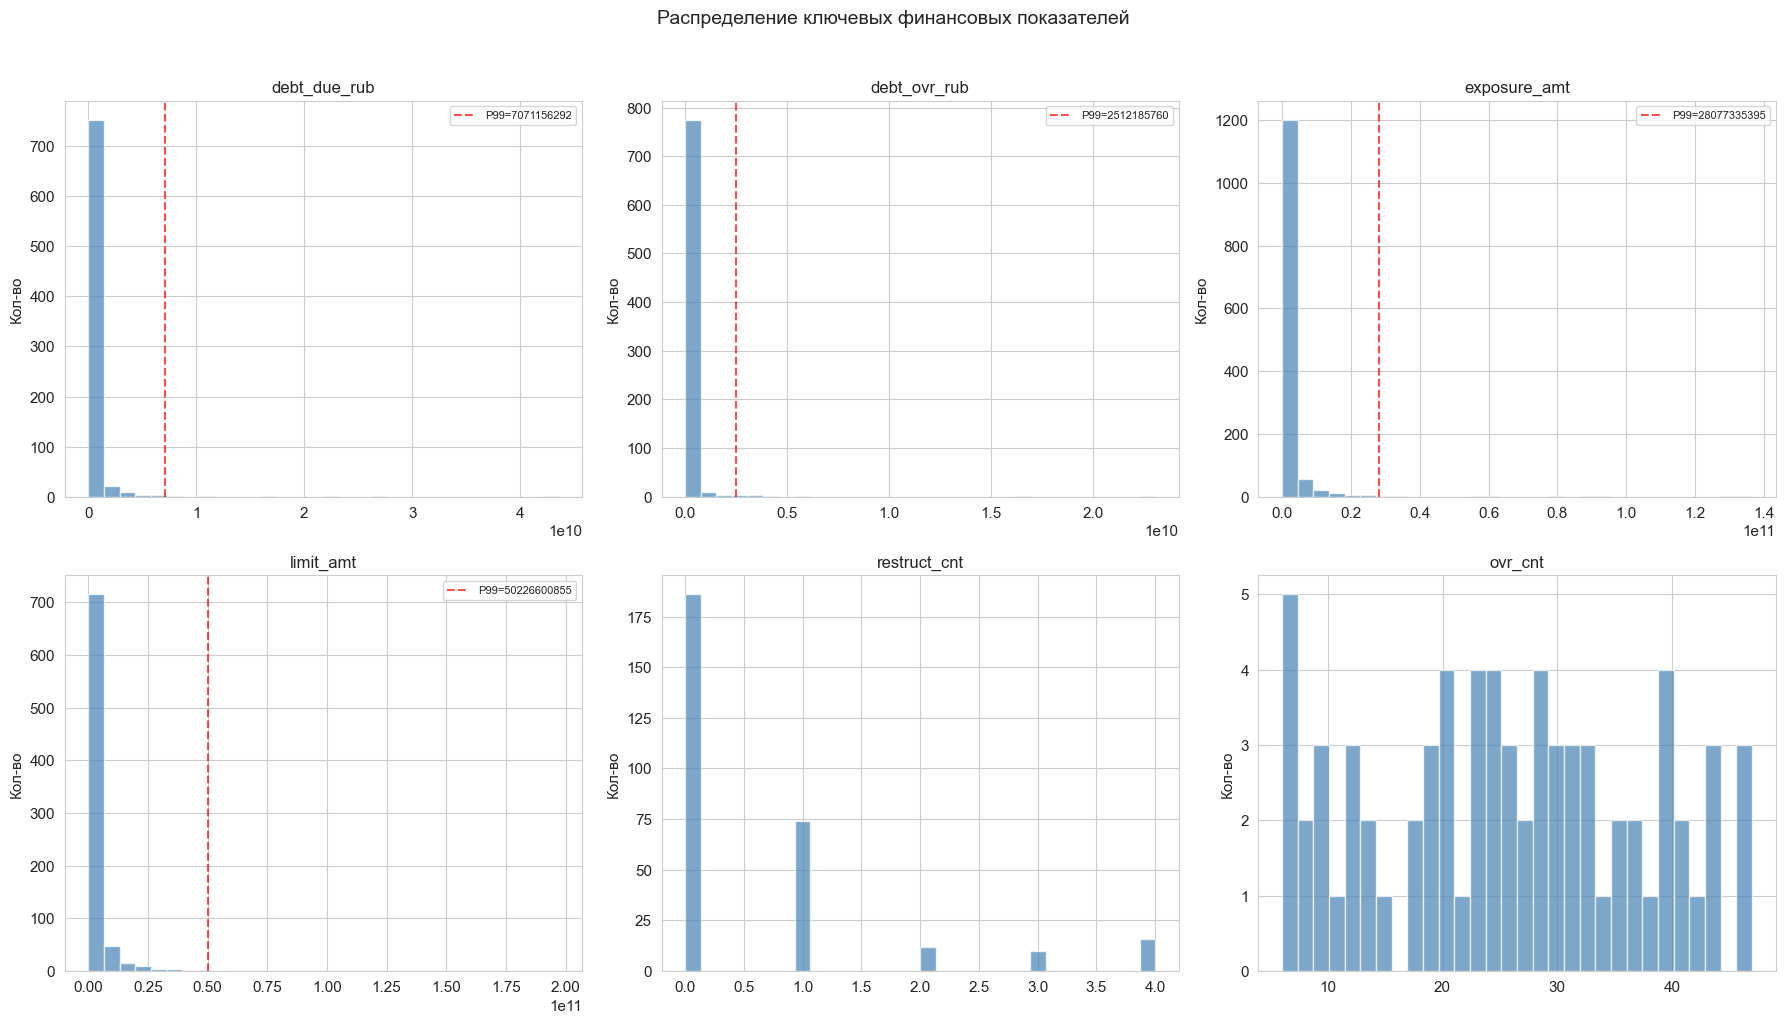

In [6]:
# ─── Распределения ключевых финансовых показателей ───
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, col in zip(axes.flatten(), ['debt_due_rub','debt_ovr_rub','exposure_amt','limit_amt','restruct_cnt','ovr_cnt']):
    data = df_last[col].dropna()
    ax.hist(data, bins=30, alpha=0.7, color='steelblue', edgecolor='white')
    ax.set_title(col, fontsize=12)
    ax.set_ylabel('Кол-во')
    # Отметим выбросы (>99-й перцентиль)
    if len(data) > 0:
        p99 = data.quantile(0.99)
        if data.max() > p99 * 1.5:
            ax.axvline(x=p99, color='red', linestyle='--', alpha=0.7, label=f'P99={p99:.0f}')
            ax.legend(fontsize=8)

plt.suptitle('Распределение ключевых финансовых показателей', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

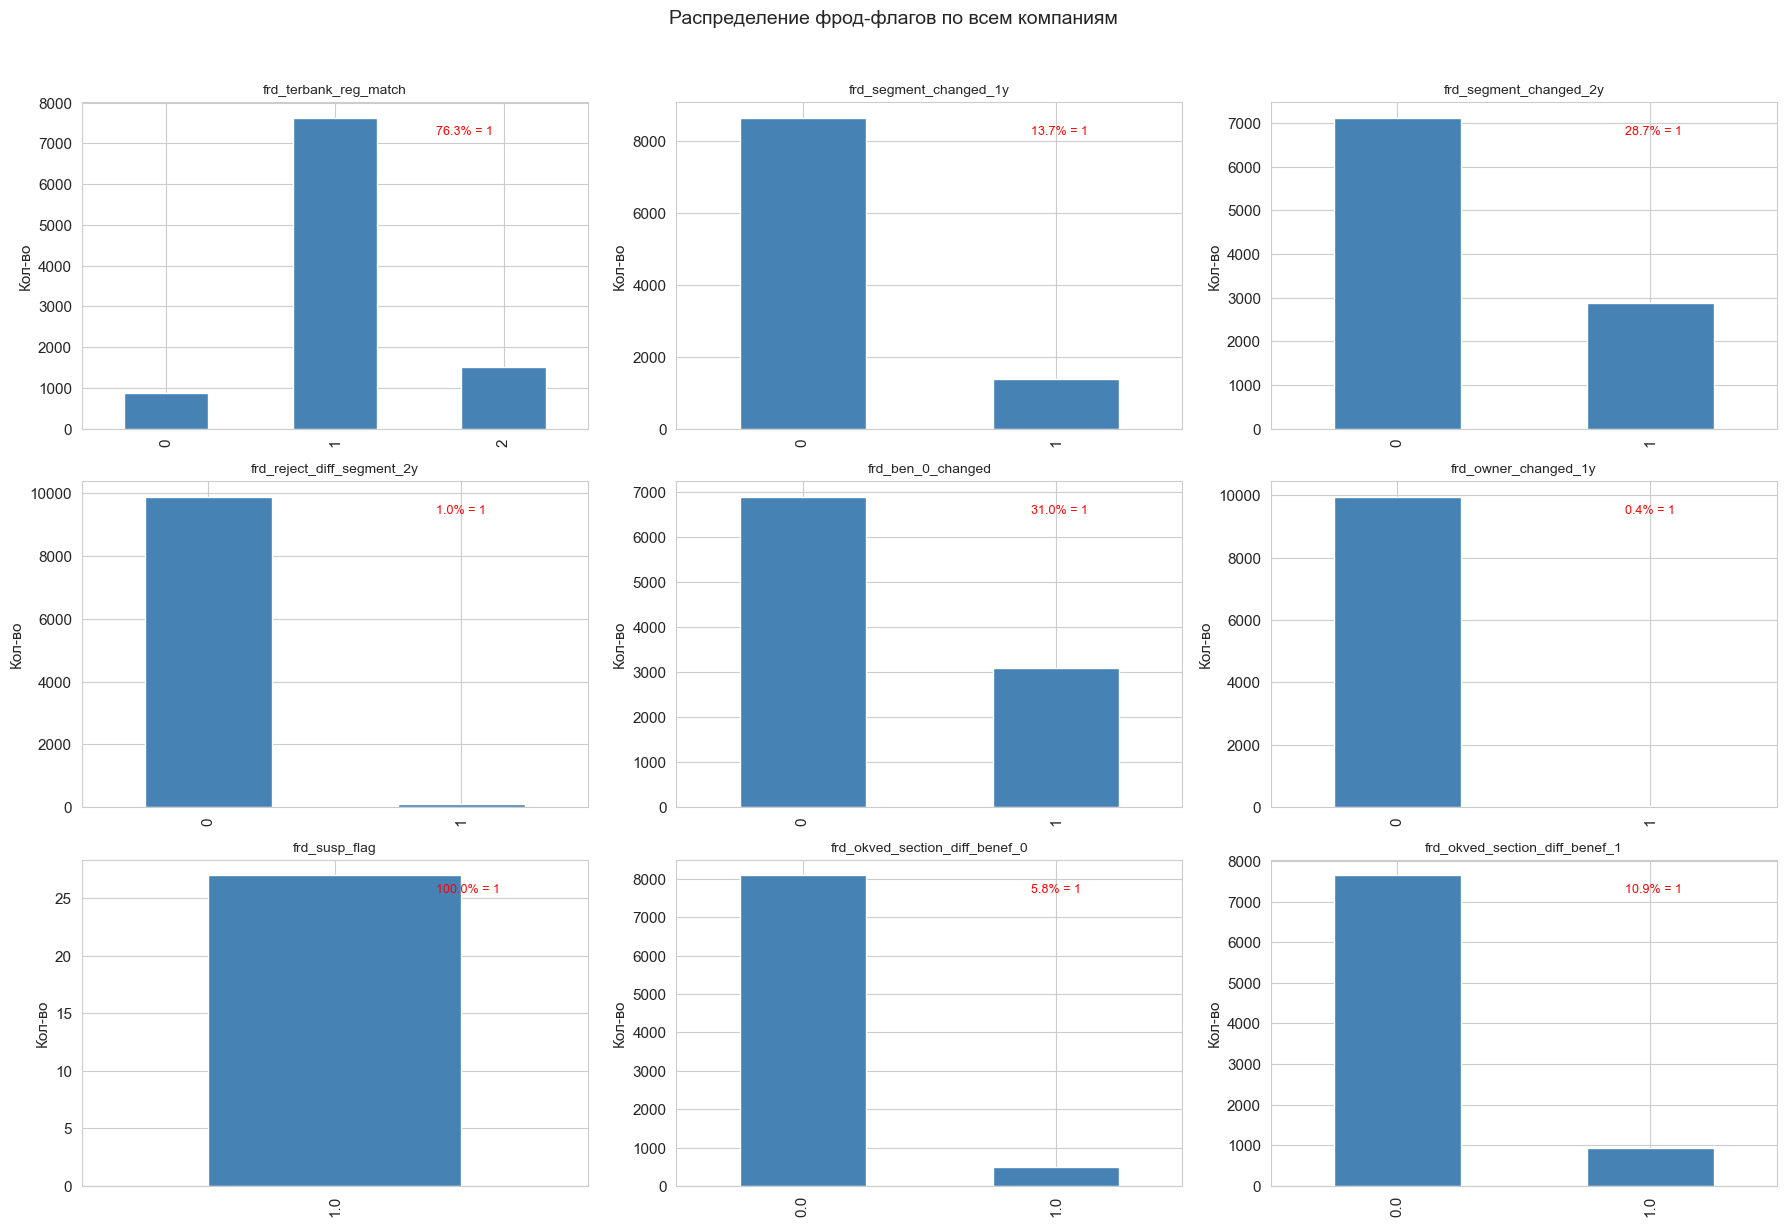

In [7]:
# ─── Фрод-флаги: распределение значений ───
frd_flags = ['frd_terbank_reg_match', 'frd_segment_changed_1y', 'frd_segment_changed_2y',
             'frd_reject_diff_segment_2y', 'frd_ben_0_changed', 'frd_owner_changed_1y',
             'frd_susp_flag', 'frd_okved_section_diff_benef_0', 'frd_okved_section_diff_benef_1']

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
for ax, flag in zip(axes.flatten(), frd_flags):
    counts = df_last[flag].value_counts().sort_index()
    counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(flag, fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel('Кол-во')
    # Доля "подозрительных" значений
    total = counts.sum()
    if 1 in counts.index:
        pct = counts.get(1, 0) / total * 100
        ax.annotate(f'{pct:.1f}% = 1', xy=(0.7, 0.9), xycoords='axes fraction', fontsize=9, color='red')

plt.suptitle('Распределение фрод-флагов по всем компаниям', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

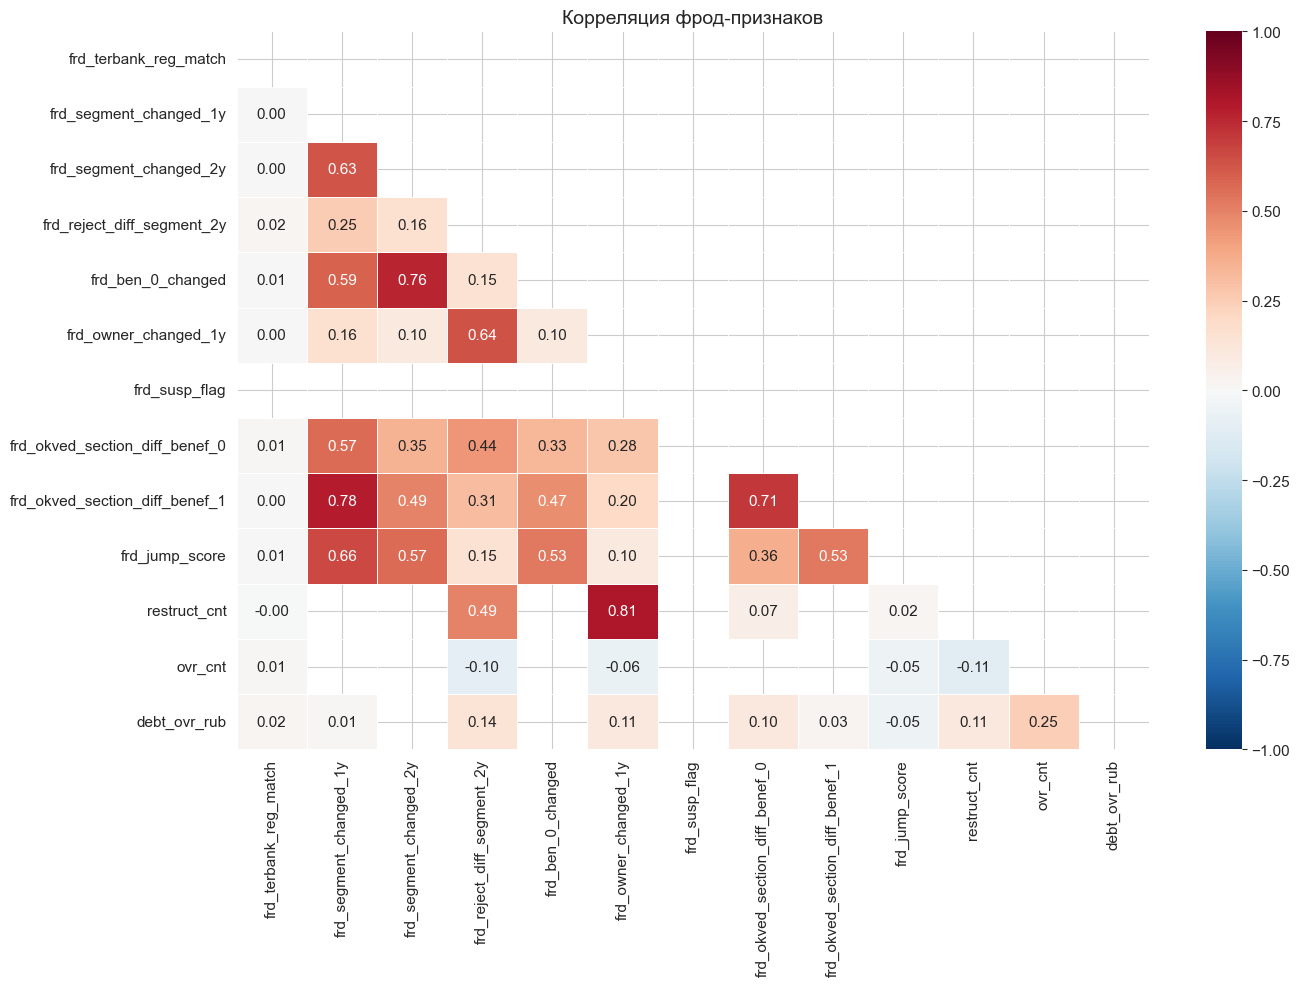

In [8]:
# ─── Корреляционная матрица фрод-релевантных признаков ───
corr_cols = ['frd_terbank_reg_match', 'frd_segment_changed_1y', 'frd_segment_changed_2y',
             'frd_reject_diff_segment_2y', 'frd_ben_0_changed', 'frd_owner_changed_1y',
             'frd_susp_flag', 'frd_okved_section_diff_benef_0', 'frd_okved_section_diff_benef_1',
             'frd_jump_score', 'restruct_cnt', 'ovr_cnt', 'debt_ovr_rub']

corr_data = df_last[corr_cols].apply(pd.to_numeric, errors='coerce')
corr_matrix = corr_data.corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.5)
plt.title('Корреляция фрод-признаков', fontsize=14)
plt.tight_layout()
plt.show()

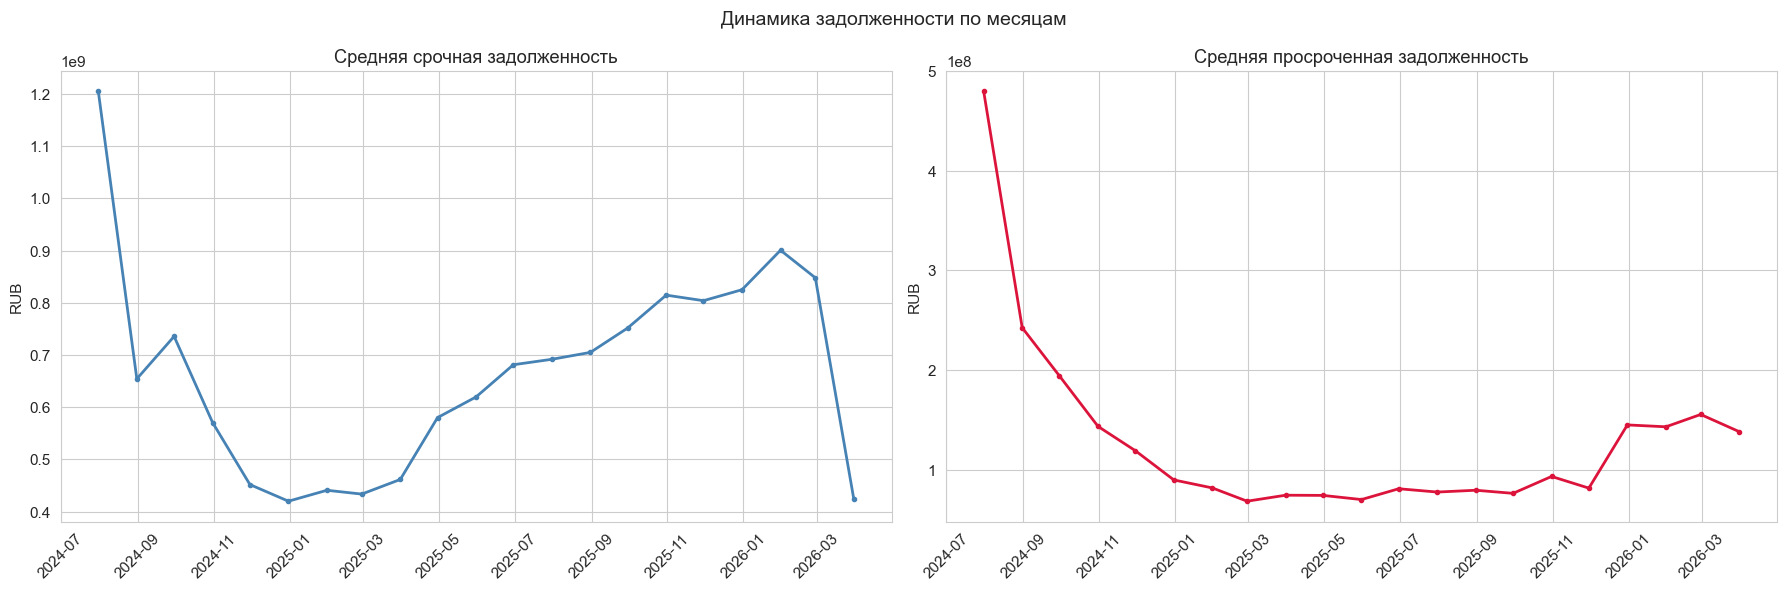

In [9]:
# ─── Динамика задолженности по snapshot_date ───
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Средняя задолженность по месяцам
agg_debt = df.groupby('snapshot_date')['debt_due_rub'].mean()
axes[0].plot(agg_debt.index, agg_debt.values, color='steelblue', linewidth=2, marker='o', markersize=3)
axes[0].set_title('Средняя срочная задолженность')
axes[0].set_ylabel('RUB')
axes[0].tick_params(axis='x', rotation=45)

# Средняя просрочка по месяцам
agg_ovr = df.groupby('snapshot_date')['debt_ovr_rub'].mean()
axes[1].plot(agg_ovr.index, agg_ovr.values, color='crimson', linewidth=2, marker='o', markersize=3)
axes[1].set_title('Средняя просроченная задолженность')
axes[1].set_ylabel('RUB')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Динамика задолженности по месяцам', fontsize=14)
plt.tight_layout()
plt.show()

## 4. Feature Engineering — фрод-признаки

Создаём агрегированные и производные признаки на уровне компании (INN), используя всю историю snapshot'ов:

In [10]:
# ─── Агрегация временных рядов на уровне INN ───
df_sorted = df.sort_values(['inn', 'snapshot_date'])

PROBLEM_GROUP_ORDINAL = {
    'Green Zone': 0, 'Без признаков': 0,
    'Watchlist': 1, 'Под наблюдением': 1,
    'Yellow Zone': 2, 'Потенциально проблемные': 2,
    'Red Zone': 3, 'Проблемные': 3,
    'Black Zone': 4, 'Безнадёжные': 4,
}

def agg_company(group):
    """Агрегация метрик компании по всем snapshot'ам."""
    last = group.iloc[-1]
    first = group.iloc[0]
    n = len(group)
    res = {}

    # Базовые атрибуты (из последнего snapshot)
    for col in ['org_id','inn','okved_cd','okved_name','okved_section','terbank',
                'org_sector','liquidation','risk_segment','segment_name','reg_region',
                'gsz_name','frd_terbank_reg_match','frd_jump_score','max_growth_pct',
                'jump_year','prev_revenue','jump_revenue','max_growth_rub',
                'frd_scheme_code','frd_susp_flag','frd_stg_name',
                'frd_okved_section_diff_benef_0','frd_okved_section_diff_benef_1',
                'frd_okved_cd_diff_benef_0','frd_okved_cd_diff_benef_1',
                'frd_liquidation_ben_0','liquidation_ben_1',
                'doc_number','signed_dt','expiration_dt','issue_dt',
                'grntee_prod_name','problem_group']:
        if col in group.columns:
            res[col] = last[col]

    # ─── Бенефициары: бинарные флаги наличия (вместо raw ID) ───
    for ben_col in ['ben_0', 'ben_1', 'ben_3', 'ben_5']:
        if ben_col in group.columns:
            res[f'has_{ben_col}'] = 1 if pd.notna(last[ben_col]) else 0
        else:
            res[f'has_{ben_col}'] = 0

    # ─── problem_group → ordinal encoding ───
    pg = last.get('problem_group') if 'problem_group' in group.columns else None
    res['problem_group_ordinal'] = PROBLEM_GROUP_ORDINAL.get(pg, -1) if pd.notna(pg) else -1

    # ─── Финансовые агрегаты ───
    res['debt_due_rub_last'] = last.get('debt_due_rub')
    res['debt_due_rub_mean'] = group['debt_due_rub'].mean()
    res['debt_due_rub_max']  = group['debt_due_rub'].max()
    res['debt_due_rub_std']  = group['debt_due_rub'].std()

    res['debt_ovr_rub_last'] = last.get('debt_ovr_rub')
    res['debt_ovr_rub_mean'] = group['debt_ovr_rub'].mean()
    res['debt_ovr_rub_max']  = group['debt_ovr_rub'].max()
    res['debt_ovr_rub_sum']  = group['debt_ovr_rub'].sum()

    res['exposure_amt_last'] = last.get('exposure_amt')
    res['limit_amt'] = last.get('limit_amt')

    res['expo_calc_last']         = last.get('expo_calc')
    res['reserv_prud_calc_last']  = last.get('reserv_prud_calc')
    res['reserv_ocen_calc_last']  = last.get('reserv_ocen_calc')

    # ─── Динамические признаки ───
    debt_first = first.get('debt_due_rub')
    debt_last  = last.get('debt_due_rub')
    if pd.notna(debt_first) and debt_first > 0 and pd.notna(debt_last):
        res['debt_growth_ratio'] = debt_last / debt_first
    else:
        res['debt_growth_ratio'] = None

    # Тренд просрочки
    ovr_series = group['debt_ovr_rub'].fillna(0)
    res['months_with_overdue'] = (ovr_series > 0).sum()
    res['overdue_month_ratio'] = res['months_with_overdue'] / n

    # Волатильность задолженности (коэф. вариации)
    mean_debt = group['debt_due_rub'].mean()
    std_debt  = group['debt_due_rub'].std()
    res['debt_cv'] = std_debt / mean_debt if pd.notna(mean_debt) and mean_debt > 0 else None

    # Максимальная просрочка к лимиту
    ovr_max = group['debt_ovr_rub'].max()
    lim = last.get('limit_amt')
    res['max_ovr_to_limit'] = ovr_max / lim if pd.notna(ovr_max) and pd.notna(lim) and lim > 0 else None

    # Резервы к exposure
    rp = last.get('reserv_prud_calc')
    ec = last.get('expo_calc')
    res['reserv_to_expo_ratio'] = rp / ec if pd.notna(rp) and pd.notna(ec) and ec > 0 else None

    # Доля snapshot'ов с заполненными финансовыми данными (полнота данных по компании)
    fin_cols_check = ['debt_due_rub','exposure_amt','expo_calc']
    avail_counts = sum(group[c].notna().sum() for c in fin_cols_check if c in group.columns)
    res['fin_data_fill_ratio'] = avail_counts / (n * len(fin_cols_check))

    # Тренд задолженности: линейный slope по snapshot'ам (нормализованный)
    debt_vals = group['debt_due_rub'].dropna()
    if len(debt_vals) >= 3:
        x_idx = np.arange(len(debt_vals), dtype=float)
        y_vals = debt_vals.values.astype(float)
        mean_y = np.nanmean(y_vals)
        if mean_y > 0:
            slope = np.polyfit(x_idx, y_vals, 1)[0]
            res['debt_trend_slope'] = slope / mean_y  # нормализованный slope
        else:
            res['debt_trend_slope'] = None
    else:
        res['debt_trend_slope'] = None

    # Тренд просрочки: нарастает ли
    ovr_vals = group['debt_ovr_rub'].dropna()
    if len(ovr_vals) >= 3:
        first_half = ovr_vals.iloc[:len(ovr_vals)//2].mean()
        second_half = ovr_vals.iloc[len(ovr_vals)//2:].mean()
        res['overdue_trend'] = (second_half - first_half) / max(first_half, 1)
    else:
        res['overdue_trend'] = None

    # Количество snapshot'ов с ненулевой задолженностью
    res['snapshots_with_debt'] = (group['debt_due_rub'].fillna(0) > 0).sum()
    res['debt_presence_ratio'] = res['snapshots_with_debt'] / n

    # ─── Фрод-флаги ───
    res['frd_segment_changed_1y'] = last.get('frd_segment_changed_1y')
    res['frd_segment_changed_2y'] = last.get('frd_segment_changed_2y')
    res['frd_reject_diff_segment_2y'] = last.get('frd_reject_diff_segment_2y')
    res['frd_ben_0_changed'] = last.get('frd_ben_0_changed')
    res['frd_owner_changed_1y'] = last.get('frd_owner_changed_1y')

    # Сколько фрод-флагов сработало (из бинарных)
    flag_sum = 0
    for fc in ['frd_segment_changed_1y','frd_segment_changed_2y',
               'frd_reject_diff_segment_2y','frd_ben_0_changed','frd_owner_changed_1y']:
        v = last.get(fc)
        if pd.notna(v) and v == 1:
            flag_sum += 1
    res['frd_flag_count'] = flag_sum

    # Реструктуризации
    res['restruct_cnt_last'] = last.get('restruct_cnt')
    res['restruct_cnt_max']  = group['restruct_cnt'].max()
    res['had_restruct'] = 1 if group['last_restruct_dt'].notna().any() else 0

    # Просрочки
    res['ovr_cnt_last'] = last.get('ovr_cnt')
    res['ovr_cnt_max']  = group['ovr_cnt'].max()

    # Дефолты
    res['had_default']    = 1 if group['default_start_dt'].notna().any() else 0
    res['in_default_now'] = 1 if pd.notna(last.get('default_start_dt')) and pd.isna(last.get('default_end_dt')) else 0

    # Суды
    res['claim_sum_max']     = group['claim_sum'].max()
    res['claim_count_total'] = group['claim_count'].sum()
    res['had_claims']        = 1 if group['claim_sum'].notna().any() else 0

    # Фрод-реестр
    res['was_in_frd_registry'] = 1 if group['frd_rgstr_sid'].notna().any() else 0
    res['frd_confirmed']       = 1 if (group['frdsgn_stts_code'] == 'CONFIRMED').any() else 0

    # Overdue OD
    res['overdue_od_last'] = last.get('overdue_od_calc')
    res['overdue_od_max']  = group['overdue_od_calc'].max()

    return pd.Series(res)

df_company = df_sorted.groupby('inn').apply(agg_company).reset_index(drop=True)

print(f"Агрегированный датасет: {df_company.shape[0]} компаний × {df_company.shape[1]} признаков")
df_company.head(3)

Агрегированный датасет: 10000 компаний × 83 признаков


,org_id,inn,okved_cd,okved_name,okved_section,terbank,org_sector,liquidation,risk_segment,segment_name,reg_region,gsz_name,frd_terbank_reg_match,frd_jump_score,max_growth_pct,jump_year,prev_revenue,jump_revenue,max_growth_rub,frd_scheme_code,frd_susp_flag,frd_stg_name,frd_okved_section_diff_benef_0,frd_okved_section_diff_benef_1,frd_okved_cd_diff_benef_0,frd_okved_cd_diff_benef_1,frd_liquidation_ben_0,liquidation_ben_1,doc_number,signed_dt,expiration_dt,issue_dt,grntee_prod_name,problem_group,has_ben_0,has_ben_1,has_ben_3,has_ben_5,problem_group_ordinal,debt_due_rub_last,debt_due_rub_mean,debt_due_rub_max,debt_due_rub_std,debt_ovr_rub_last,debt_ovr_rub_mean,debt_ovr_rub_max,debt_ovr_rub_sum,exposure_amt_last,limit_amt,expo_calc_last,reserv_prud_calc_last,reserv_ocen_calc_last,debt_growth_ratio,months_with_overdue,overdue_month_ratio,debt_cv,max_ovr_to_limit,reserv_to_expo_ratio,fin_data_fill_ratio,debt_trend_slope,overdue_trend,snapshots_with_debt,debt_presence_ratio,frd_segment_changed_1y,frd_segment_changed_2y,frd_reject_diff_segment_2y,frd_ben_0_changed,frd_owner_changed_1y,frd_flag_count,restruct_cnt_last,restruct_cnt_max,had_restruct,ovr_cnt_last,ovr_cnt_max,had_default,in_default_now,claim_sum_max,claim_count_total,had_claims,was_in_frd_registry,frd_confirmed,overdue_od_last,overdue_od_max
0,1199000000022125686,1000000000,L47.30,Операции с недвижимостью,L,Московский банк,Недвижимость,Действующее,Кредитование корпоративных клиентов,Рег. госсектор,москва,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0.00,0.00,0.00,Действующее,Действующее,NaN,NaT,NaT,NaT,NaN,NaN,1,1,1,1,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN,NaN,NaN,None,0,0.00,NaN,NaN,NaN,0.00,NaN,NaN,0,0.00,0,0,0,0,0,0,NaN,NaN,0,NaN,NaN,0,0,NaN,0.00,0,0,0,NaN,NaN
1,1199000000018490865,1000000001,L39.57,Операции с недвижимостью,L,Центрально-Черноземный банк,Недвижимость,Действующее,Кредитование корпоративных клиентов,Рег. госсектор,курская область,ГСЗ_627,1,0.70,288.61,2024.00,16976699.24,65973150.92,48996451.68,NaN,NaN,NaN,1.00,1.00,1.00,1.00,Действующее,Действующее,КД-741753,2022-03-13,2026-05-04,NaT,Гарантия,Black Zone,1,1,1,1,4,87192554.42,101779737.57,160118937.64,28489735.49,0.00,0.00,0.00,0.00,102485631.80,76192325.91,70624045.34,17311091.48,14671665.93,None,0,0.00,0.28,0.00,0.25,0.63,0.03,0.00,19,0.70,1,1,0,1,0,3,NaN,NaN,0,NaN,NaN,0,0,8720984450.01,2232.00,1,0,0,10236038.33,40338149.05
2,1199000000004854347,1000000002,F06.60,Строительство,F,Среднерусский банк,Строительство,Действующее,Контрактное финансирование (прочее кредитование),Рег. госсектор,калужская область,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0.00,0.00,0.00,Действующее,Действующее,NaN,NaT,NaT,NaT,NaN,Watchlist,1,1,1,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN,NaN,NaN,None,0,0.00,NaN,NaN,NaN,0.00,NaN,NaN,0,0.00,0,0,0,0,0,0,NaN,NaN,0,NaN,NaN,0,0,NaN,0.00,0,0,0,NaN,NaN


In [11]:
# 1. Data completeness score — компании с аномально неполными данными
key_fields = ['debt_due_rub_last', 'exposure_amt_last', 'limit_amt',
              'expo_calc_last', 'risk_segment', 'claim_sum_max',
              'frd_jump_score', 'has_ben_0', 'problem_group']
df_company['data_completeness'] = df_company[key_fields].notna().sum(axis=1) / len(key_fields)

# 2. Log-трансформации финансовых признаков (для адекватного ML на разреженных данных)
log_cols = ['debt_due_rub_last','debt_due_rub_max','debt_ovr_rub_max','debt_ovr_rub_sum',
            'exposure_amt_last','limit_amt','expo_calc_last',
            'reserv_prud_calc_last','reserv_ocen_calc_last','claim_sum_max',
            'overdue_od_max']
for col in log_cols:
    if col in df_company.columns:
        df_company[f'log_{col}'] = np.log1p(df_company[col].clip(lower=0).fillna(0))

# 3. Exposure vs Debt mismatch — exposure >> 0 при отсутствии долга
debt_v = df_company['debt_due_rub_last'].fillna(0)
expo_v = df_company['expo_calc_last'].fillna(0)
df_company['expo_debt_mismatch'] = ((expo_v > 1e6) & (debt_v == 0)).astype(int)

# 4. Reserv/Expo anomaly — резервы > 50% от exposure (повышенный риск)
reserv_v = df_company['reserv_prud_calc_last'].fillna(0)
df_company['reserv_expo_anomaly'] = 0
mask_hi = (expo_v > 0) & (reserv_v / expo_v.replace(0, np.nan) > 0.5)
df_company.loc[mask_hi, 'reserv_expo_anomaly'] = 1

# 5. Beneficiary risk composite — агрегированный риск по бенефициарам
df_company['beneficiary_risk'] = (
    df_company['frd_okved_section_diff_benef_0'].fillna(0).astype(float) * 0.25 +
    df_company['frd_okved_section_diff_benef_1'].fillna(0).astype(float) * 0.15 +
    df_company['frd_ben_0_changed'].fillna(0).astype(float) * 0.35 +
    (df_company['frd_liquidation_ben_0'].isin(['В стадии ликвидации', 'Ликвидировано'])).astype(float) * 0.25
)

# 6. Claims intensity — отношение исков к exposure
df_company['claims_to_expo'] = (
    df_company['claim_sum_max'].fillna(0) /
    df_company['expo_calc_last'].replace(0, np.nan).fillna(1e12)  # avoid div/0
)

# 7. Zero debt anomaly — долг = 0 но есть иски/дефолт, И при этом есть реальные фин. данные
df_company['zero_debt_anomaly'] = (
    (df_company['debt_due_rub_last'].fillna(0) == 0) &
    ((df_company['had_claims'] == 1) | (df_company['in_default_now'] == 1)) &
    (df_company['fin_data_fill_ratio'] > 0.1)
).astype(int)

# 8. Overdue severity composite
df_company['overdue_severity'] = (
    df_company['overdue_month_ratio'].fillna(0) * 0.4 +
    (df_company['ovr_cnt_max'].fillna(0) > 5).astype(float) * 0.3 +
    df_company['in_default_now'].fillna(0).astype(float) * 0.3
)

# 9. frd_susp_flag (бинарный, из витрины)
df_company['frd_susp_binary'] = df_company['frd_susp_flag'].fillna(0).astype(float).clip(0, 1)

# 10. Debt utilization — долг к лимиту (утилизация)
df_company['debt_to_limit'] = (
    df_company['debt_due_rub_last'].fillna(0) /
    df_company['limit_amt'].replace(0, np.nan).fillna(1e12)
).clip(0, 10)  # cap at 10x

# 11. Overdue to debt ratio — просрочка к общей задолженности
df_company['ovr_to_debt_ratio'] = (
    df_company['debt_ovr_rub_max'].fillna(0) /
    df_company['debt_due_rub_max'].replace(0, np.nan).fillna(1e12)
).clip(0, 10)

# 12. Claims per snapshot — интенсивность судебных исков
n_snapshots = df['snapshot_date'].nunique()
df_company['claims_intensity'] = df_company['claim_count_total'].fillna(0) / n_snapshots

# 13. Multi-method FRD flag (количество одновременных признаков из витрины)
# frd_flag_count уже посчитан в agg_company
n_log = sum(1 for c in df_company.columns if c.startswith('log_'))
print(f"Добавлено: {n_log} log-трансформаций + 12 расчётных признаков")
print(f"Итого признаков df_company: {df_company.shape[1]}")

new_binary = ['expo_debt_mismatch', 'reserv_expo_anomaly', 'zero_debt_anomaly', 'frd_susp_binary']
print(f"\nНовые бинарные признаки (доля = 1):")
for col in new_binary:
    pct = df_company[col].sum() / len(df_company) * 100
    print(f"  {col}: {df_company[col].sum():,.0f} ({pct:.2f}%)")

print(f"\ndata_completeness: mean={df_company['data_completeness'].mean():.3f}, "
      f"min={df_company['data_completeness'].min():.3f}")
print(f"frd_flag_count: mean={df_company['frd_flag_count'].mean():.2f}, "
      f"max={df_company['frd_flag_count'].max():.0f}")
print(f"beneficiary_risk: mean={df_company['beneficiary_risk'].mean():.3f}")
print(f"overdue_severity: mean={df_company['overdue_severity'].mean():.3f}")
print(f"fin_data_fill_ratio: mean={df_company['fin_data_fill_ratio'].mean():.3f}")
print(f"problem_group_ordinal: distribution:")
print(df_company['problem_group_ordinal'].value_counts().sort_index())

Добавлено: 11 log-трансформаций + 12 расчётных признаков
Итого признаков df_company: 105

Новые бинарные признаки (доля = 1):
  expo_debt_mismatch: 947 (9.47%)
  reserv_expo_anomaly: 32 (0.32%)
  zero_debt_anomaly: 1,003 (10.03%)
  frd_susp_binary: 27 (0.27%)

data_completeness: mean=0.416, min=0.222
frd_flag_count: mean=0.75, max=5
beneficiary_risk: mean=0.136
overdue_severity: mean=0.013
fin_data_fill_ratio: mean=0.067
problem_group_ordinal: distribution:
problem_group_ordinal
-1    5576
 0    2569
 1    1022
 2      10
 3      80
 4     743
Name: count, dtype: int64


## 4. Rule-based детекция (эвристические правила)

Набор бизнес-правил для выявления подозрительных компаний на основе экспертных знаний антифрод-аналитиков:

Распределение rule_score:
count   10000.00
mean       15.48
std        24.71
min         0.00
25%         0.00
50%         5.00
75%        18.00
max       100.00
Name: rule_score, dtype: float64

Компании с rule_score >= 40: 1519
Компании с rule_score >= 25: 2098
Компании с rule_score > 0:   5092

Топ-15 срабатываний правил:
  R12:HIGH_CLAIMS: 4,162 (41.6%)
  R5:BENEFICIARY_CHANGED: 3,101 (31.0%)
  R3:SEGMENT_CHANGED_2Y: 2,875 (28.7%)
  R1:REVENUE_JUMP: 2,013 (20.1%)
  R3:SEGMENT_CHANGED_1Y: 1,367 (13.7%)
  R18:MULTI_FRD_FLAGS: 1,358 (13.6%)
  R19:ZERO_DEBT_ANOMALY: 1,003 (10.0%)
  R7:OKVED_DIFF_BEN1: 937 (9.4%)
  R2:TB_REG_MISMATCH: 870 (8.7%)
  R15:PROBLEM_GROUP: 833 (8.3%)
  R7:OKVED_DIFF_BEN0: 495 (5.0%)
  R16:HIGH_RESERV_RATIO: 444 (4.4%)
  R9:HIGH_OVERDUE_RATIO: 197 (2.0%)
  R11:IN_DEFAULT_NOW: 172 (1.7%)
  R13:FRD_REGISTRY: 120 (1.2%)


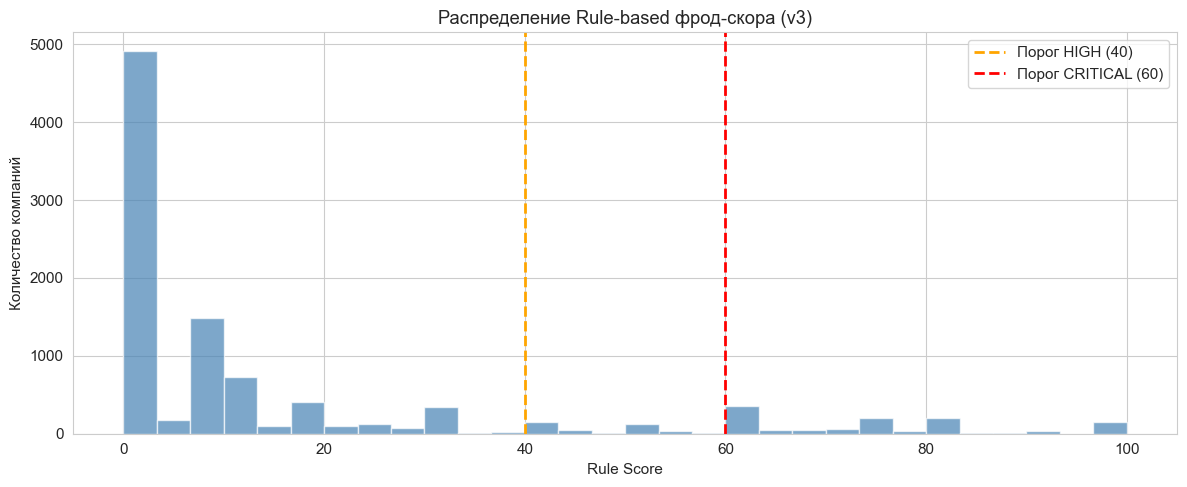

In [12]:
def apply_fraud_rules_v3(row):
    """Применяем набор эвристических правил. Возвращаем скор (0-100) и список сработавших правил."""
    score = 0
    reasons = []

    # R1: Взрывной рост выручки (frd_jump_score > 0.5 = подозрительно)
    js = row.get('frd_jump_score')
    if pd.notna(js) and js > 0.5:
        score += 15
        reasons.append(f'R1:REVENUE_JUMP>{js:.0%}')

    # R2: Регион ТБ не совпадает с регистрацией (frd_terbank_reg_match == 0, ~8.7%)
    if row.get('frd_terbank_reg_match') == 0:
        score += 8
        reasons.append('R2:TB_REG_MISMATCH')

    # R3: Смена сегмента за 1-2 года (~13.7% / ~28.8%)
    if row.get('frd_segment_changed_1y') == 1:
        score += 10
        reasons.append('R3:SEGMENT_CHANGED_1Y')
    if row.get('frd_segment_changed_2y') == 1:
        score += 5
        reasons.append('R3:SEGMENT_CHANGED_2Y')

    # R4: Отказ при ином сегменте (~1.0%)
    if row.get('frd_reject_diff_segment_2y') == 1:
        score += 12
        reasons.append('R4:REJECT_DIFF_SEGMENT')

    # R5: Смена бенефициара (~31% — распространённо, поэтому +5 вместо +10)
    if row.get('frd_ben_0_changed') == 1:
        score += 5
        reasons.append('R5:BENEFICIARY_CHANGED')

    # R6: Смена собственника (<0.5% — очень редко, сильный сигнал)
    if row.get('frd_owner_changed_1y') == 1:
        score += 12
        reasons.append('R6:OWNER_CHANGED_1Y')

    # R7: ОКВЭД клиента ≠ ОКВЭД бенефициаров (~74% / ~67% — норма для рынка!)
    okved0 = row.get('frd_okved_section_diff_benef_0')
    okved1 = row.get('frd_okved_section_diff_benef_1')
    if pd.notna(okved0) and okved0 == 1:
        score += 2
        reasons.append('R7:OKVED_DIFF_BEN0')
    if pd.notna(okved1) and okved1 == 1:
        score += 1
        reasons.append('R7:OKVED_DIFF_BEN1')

    # R8: Ликвидация бенефициара
    if row.get('frd_liquidation_ben_0') in ['В стадии ликвидации', 'Ликвидировано']:
        score += 12
        reasons.append('R8:BEN0_LIQUIDATED')
    if row.get('liquidation_ben_1') in ['В стадии ликвидации', 'Ликвидировано']:
        score += 8
        reasons.append('R8:BEN1_LIQUIDATED')

    # R9: Высокий уровень просрочки (доля месяцев с просрочкой > 50%)
    omr = row.get('overdue_month_ratio')
    if pd.notna(omr) and omr > 0.5:
        score += 10
        reasons.append(f'R9:HIGH_OVERDUE_RATIO={omr:.0%}')

    # R10: Множественные реструктуризации (>=2)
    rc = row.get('restruct_cnt_max')
    if pd.notna(rc) and rc >= 2:
        score += 8
        reasons.append(f'R10:RESTRUCT_CNT={int(rc)}')

    # R11: Текущий или исторический дефолт
    if row.get('in_default_now') == 1:
        score += 15
        reasons.append('R11:IN_DEFAULT_NOW')
    elif row.get('had_default') == 1:
        score += 7
        reasons.append('R11:HAD_DEFAULT')

    # R12: Крупные судебные иски (>10M руб)
    cs = row.get('claim_sum_max')
    if pd.notna(cs) and cs > 1e7:
        score += 8
        reasons.append(f'R12:HIGH_CLAIMS={cs/1e6:.0f}M')

    # R13: Фрод-реестр
    if row.get('was_in_frd_registry') == 1:
        score += 15
        reasons.append('R13:FRD_REGISTRY')
    if row.get('frd_confirmed') == 1:
        score += 10
        reasons.append('R13:FRD_CONFIRMED')

    # R14: Высокий риск-сегмент
    if row.get('risk_segment') == 'Высокий':
        score += 8
        reasons.append('R14:HIGH_RISK_SEGMENT')

    # R15: Проблемная группа (поддержка и русских и английских названий)
    pg = row.get('problem_group')
    if pg in ['Проблемные', 'Red Zone']:
        score += 8
        reasons.append(f'R15:PROBLEM_GROUP={pg}')
    elif pg in ['Безнадёжные', 'Black Zone']:
        score += 12
        reasons.append(f'R15:PROBLEM_GROUP={pg}')
    elif pg in ['Потенциально проблемные', 'Yellow Zone']:
        score += 5
        reasons.append(f'R15:PROBLEM_GROUP={pg}')

    # R16: Высокое отношение резервов к exposure (>30%)
    rte = row.get('reserv_to_expo_ratio')
    if pd.notna(rte) and rte > 0.3:
        score += 6
        reasons.append(f'R16:HIGH_RESERV_RATIO={rte:.1%}')

    # R17: Рост задолженности > 2x
    dg = row.get('debt_growth_ratio')
    if pd.notna(dg) and dg > 2.0:
        score += 10
        reasons.append(f'R17:DEBT_GROWTH={dg:.1f}x')

    # R18: Множественные одновременные фрод-флаги (>=3 из 5)
    ffc = row.get('frd_flag_count', 0)
    if pd.notna(ffc) and ffc >= 3:
        score += 10
        reasons.append(f'R18:MULTI_FRD_FLAGS={int(ffc)}')

    # R19: Zero debt anomaly — нет долга, но есть иски/дефолт (upstream fix: только при наличии фин. данных)
    if row.get('zero_debt_anomaly') == 1:
        score += 8
        reasons.append('R19:ZERO_DEBT_ANOMALY')

    # R20: Подозрительный по данным витрины (frd_susp_flag)
    if row.get('frd_susp_binary') == 1:
        score += 10
        reasons.append('R20:FRD_SUSP_FLAG')

    return min(score, 100), '|'.join(reasons) if reasons else 'CLEAN'

# Применяем правила
df_company[['rule_score', 'rule_reasons']] = df_company.apply(
    lambda r: pd.Series(apply_fraud_rules_v3(r)), axis=1
)

print("Распределение rule_score:")
print(df_company['rule_score'].describe())
print(f"\nКомпании с rule_score >= 40: {(df_company['rule_score'] >= 40).sum()}")
print(f"Компании с rule_score >= 25: {(df_company['rule_score'] >= 25).sum()}")
print(f"Компании с rule_score > 0:   {(df_company['rule_score'] > 0).sum()}")

# Топ-10 самых частых правил
from collections import Counter
all_rules = []
for reasons in df_company['rule_reasons']:
    if reasons != 'CLEAN':
        for r in reasons.split('|'):
            rule_code = r.split(':')[0] + ':' + r.split(':')[1].split('=')[0].split('>')[0] if ':' in r else r
            all_rules.append(rule_code)
rule_freq = Counter(all_rules).most_common(15)
print(f"\nТоп-15 срабатываний правил:")
for rule, cnt in rule_freq:
    pct = cnt / len(df_company) * 100
    print(f"  {rule}: {cnt:,} ({pct:.1f}%)")

# Гистограмма
fig, ax = plt.subplots(figsize=(12, 5))
df_company['rule_score'].hist(bins=30, alpha=0.7, color='steelblue', edgecolor='white', ax=ax)
ax.axvline(x=40, color='orange', linestyle='--', linewidth=2, label='Порог HIGH (40)')
ax.axvline(x=60, color='red', linestyle='--', linewidth=2, label='Порог CRITICAL (60)')
ax.set_xlabel('Rule Score')
ax.set_ylabel('Количество компаний')
ax.set_title('Распределение Rule-based фрод-скора (v3)')
ax.legend()
plt.tight_layout()
plt.show()

## 5. ML-модели для детекции аномалий

### 5.1 Подготовка признаков для ML
### 5.2 Isolation Forest
### 5.3 Local Outlier Factor (LOF)
### 5.4 DBSCAN кластеризация
### 5.5 PCA визуализация

In [13]:
# ─── 5.1 Подготовка признаков для ML (v3) ───

ml_features = [
    # ─── Фрод-флаги из витрины ───
    'frd_terbank_reg_match', 'frd_segment_changed_1y', 'frd_segment_changed_2y',
    'frd_reject_diff_segment_2y', 'frd_ben_0_changed',
    'frd_susp_binary',
    'frd_okved_section_diff_benef_0', 'frd_okved_section_diff_benef_1',
    'frd_okved_cd_diff_benef_0', 'frd_okved_cd_diff_benef_1',
    'frd_jump_score',

    # ─── Финансовые (log-transformed) ───
    'log_debt_due_rub_last', 'log_debt_due_rub_max',
    'log_exposure_amt_last', 'log_limit_amt',
    'log_expo_calc_last',
    'log_reserv_prud_calc_last', 'log_reserv_ocen_calc_last',
    'log_claim_sum_max',

    # ─── Расчётные raw ───
    'debt_due_rub_std',
    'debt_growth_ratio',
    'debt_cv', 'reserv_to_expo_ratio',

    # ─── Бинарные события ───
    'had_default', 'in_default_now', 'had_claims',
    'was_in_frd_registry',

    # ─── Бенефициары (бинарные флаги наличия) ───
    'has_ben_0', 'has_ben_1', 'has_ben_3', 'has_ben_5',

    # ─── Новые v3 признаки ───
    'problem_group_ordinal',
    'data_completeness', 'fin_data_fill_ratio',
    'expo_debt_mismatch', 'reserv_expo_anomaly',
    'beneficiary_risk', 'claims_to_expo',
    'zero_debt_anomaly', 'overdue_severity',
    'debt_to_limit', 'ovr_to_debt_ratio',
    'claims_intensity', 'frd_flag_count',
    'debt_presence_ratio',
]

# Оставляем только те признаки, что реально есть в данных
ml_features = [f for f in ml_features if f in df_company.columns]

# Подготовка числовой матрицы
X = df_company[ml_features].copy()
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors='coerce')

# Замена inf на NaN
X = X.replace([np.inf, -np.inf], np.nan)

# Заполнение пропусков медианой
X = X.fillna(X.median())

# Если после median fill остались NaN (столбец полностью null) -> заполняем 0
X = X.fillna(0)

# Масштабирование
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=ml_features)

print(f"ML матрица: {X_scaled_df.shape}")
print(f"Признаков: {len(ml_features)}")
print(f"Пропуски после заполнения: {np.isnan(X_scaled).sum()}")
print(f"Inf значения: {np.isinf(X_scaled).sum()}")

# Процент ненулевых значений по фичам (для оценки полезности)
nonzero_pct = (X != 0).sum() / len(X) * 100
low_info = nonzero_pct[nonzero_pct < 5].sort_values()
if len(low_info) > 0:
    print(f"\nПризнаки с <5% ненулевых значений (возможно низкая информативность):")
    for feat, pct in low_info.items():
        print(f"  {feat}: {pct:.1f}% ненулевых")

ML матрица: (10000, 45)
Признаков: 45
Пропуски после заполнения: 0
Inf значения: 0

Признаки с <5% ненулевых значений (возможно низкая информативность):
  debt_growth_ratio: 0.0% ненулевых
  frd_susp_binary: 0.3% ненулевых
  reserv_expo_anomaly: 0.3% ненулевых
  frd_reject_diff_segment_2y: 1.0% ненулевых
  was_in_frd_registry: 1.2% ненулевых
  in_default_now: 1.7% ненулевых
  had_default: 1.9% ненулевых
  overdue_severity: 2.0% ненулевых
  ovr_to_debt_ratio: 2.0% ненулевых
  log_debt_due_rub_last: 3.1% ненулевых
  debt_to_limit: 3.1% ненулевых
  frd_okved_section_diff_benef_0: 5.0% ненулевых
  frd_okved_cd_diff_benef_0: 5.0% ненулевых


In [14]:
# ─── 5.2 Isolation Forest (v2) ───

iso_forest = IsolationForest(
    n_estimators=300,
    contamination=0.06,
    max_samples=min(10000, len(X_scaled)),  # ограничиваем subsample для скорости
    random_state=42,
    n_jobs=-1
)
df_company['iso_score'] = iso_forest.fit_predict(X_scaled)
df_company['iso_anomaly_score'] = -iso_forest.decision_function(X_scaled)

# Нормализуем в 0-100
iso_min, iso_max = df_company['iso_anomaly_score'].min(), df_company['iso_anomaly_score'].max()
df_company['iso_score_norm'] = ((df_company['iso_anomaly_score'] - iso_min) / (iso_max - iso_min) * 100).round(1)

iso_anomalies = df_company[df_company['iso_score'] == -1]
print(f"Isolation Forest: {len(iso_anomalies)} аномалий из {len(df_company)} ({len(iso_anomalies)/len(df_company):.1%})")
print(f"Топ-5 по anomaly score:")
print(iso_anomalies.nlargest(5, 'iso_score_norm')[['inn','org_id','iso_score_norm']].to_string(index=False))

# Пересечение с rule-based
iso_and_rules = df_company[(df_company['iso_score'] == -1) & (df_company['rule_score'] >= 40)]
print(f"\nIsolation Forest ∩ Rule-based(>=40): {len(iso_and_rules)} компаний")
print(f"ISO anomalies со средним rule_score: {iso_anomalies['rule_score'].mean():.1f}")

Isolation Forest: 573 аномалий из 10000 (5.7%)
Топ-5 по anomaly score:
       inn              org_id  iso_score_norm
1000002267 1199000000003436846          100.00
1000007423 1199000000049715482           98.90
1000000534 1199000000054276826           97.70
1000007729 1199000000044686917           97.50
1000008815 1199000000047521919           97.50

Isolation Forest ∩ Rule-based(>=40): 384 компаний
ISO anomalies со средним rule_score: 57.1


In [15]:
# ─── 5.3 Local Outlier Factor (v2) ───
# n_neighbors увеличен: 20 → 50 (лучше для 230К компаний)
# contamination снижен: 0.15 → 0.06

lof = LocalOutlierFactor(
    n_neighbors=50,
    contamination=0.06,
    metric='euclidean',
    n_jobs=-1
)
df_company['lof_pred'] = lof.fit_predict(X_scaled)
df_company['lof_score'] = -lof.negative_outlier_factor_

# Нормализация 0-100
lof_min, lof_max = df_company['lof_score'].min(), df_company['lof_score'].max()
df_company['lof_score_norm'] = ((df_company['lof_score'] - lof_min) / (lof_max - lof_min) * 100).round(1)

lof_anomalies = df_company[df_company['lof_pred'] == -1]
print(f"LOF: {len(lof_anomalies)} аномалий из {len(df_company)} ({len(lof_anomalies)/len(df_company):.1%})")
print(f"Топ-5 по LOF score:")
print(lof_anomalies.nlargest(5, 'lof_score_norm')[['inn','org_id','lof_score_norm']].to_string(index=False))

# Пересечение LOF и ISO
lof_and_iso = df_company[(df_company['lof_pred'] == -1) & (df_company['iso_score'] == -1)]
print(f"\nLOF ∩ ISO: {len(lof_and_iso)} компаний (общие аномалии)")
print(f"LOF anomalies со средним rule_score: {lof_anomalies['rule_score'].mean():.1f}")

LOF: 379 аномалий из 10000 (3.8%)
Топ-5 по LOF score:
       inn              org_id  lof_score_norm
1000009743 1199000000009566152          100.00
1000000799 1199000000075610612           72.20
1000001726 1199000000071674869           72.20
1000005326 1199000000074272301           72.20
1000009488 1199000000045296680           72.20

LOF ∩ ISO: 57 компаний (общие аномалии)
LOF anomalies со средним rule_score: 2.5


PCA для DBSCAN: 15 компонент, объяснённая дисперсия: 94.1%


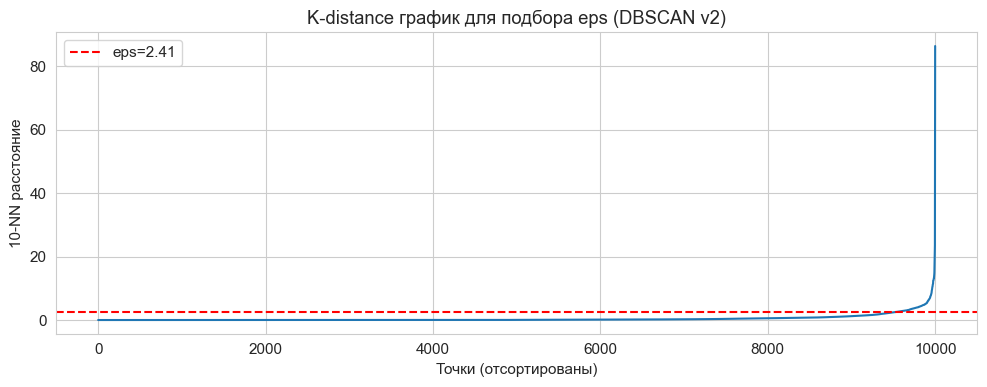


DBSCAN: 11 кластеров (вкл. шум)
Шум (cluster=-1): 386 компаний (3.9%)

Топ кластеров по размеру:
                count  mean_rule_score
dbscan_cluster                        
 0               7286             8.50
 1               1416             0.80
 2                689            63.00
-1                386            81.70
 3                 97            79.60
 6                 37            79.40
 5                 33            73.20
 4                 21            47.70
 7                 15            78.00
 8                 10            62.00
 9                 10            72.20


In [16]:
# ─── 5.4 DBSCAN кластеризация (v2) ───
# Изменения:
#   - PCA 10→15 компонент (больше признаков)
#   - min_samples=10 (вместо 3 — меньше микро-кластеров для 230К)
#   - eps по 95-му перцентилю (вместо 90-го — агрессивнее группируем)

pca_for_db = PCA(n_components=15, random_state=42)
X_pca_db = pca_for_db.fit_transform(X_scaled)
print(f"PCA для DBSCAN: {X_pca_db.shape[1]} компонент, "
      f"объяснённая дисперсия: {pca_for_db.explained_variance_ratio_.sum():.1%}")

# K-distance для подбора eps
nn = NearestNeighbors(n_neighbors=10)
nn.fit(X_pca_db)
distances, _ = nn.kneighbors(X_pca_db)
k_distances = np.sort(distances[:, -1])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(k_distances)
ax.set_xlabel('Точки (отсортированы)')
ax.set_ylabel('10-NN расстояние')
ax.set_title('K-distance график для подбора eps (DBSCAN v2)')
eps_val = np.percentile(k_distances, 95)
ax.axhline(y=eps_val, color='red', linestyle='--', label=f'eps={eps_val:.2f}')
ax.legend()
plt.tight_layout()
plt.show()

dbscan = DBSCAN(eps=eps_val, min_samples=10)
df_company['dbscan_cluster'] = dbscan.fit_predict(X_pca_db)

n_clusters = df_company['dbscan_cluster'].nunique()
n_noise = (df_company['dbscan_cluster'] == -1).sum()
print(f"\nDBSCAN: {n_clusters} кластеров (вкл. шум)")
print(f"Шум (cluster=-1): {n_noise} компаний ({n_noise/len(df_company):.1%})")

# Статистика кластеров (топ-10 + шум)
cluster_stats = df_company.groupby('dbscan_cluster').agg(
    count=('inn', 'count'),
    mean_rule_score=('rule_score', 'mean')
).round(1)
# Показываем шум + топ-10 крупных кластеров
top_clusters = cluster_stats.sort_values('count', ascending=False).head(11)
print(f"\nТоп кластеров по размеру:")
print(top_clusters.to_string())

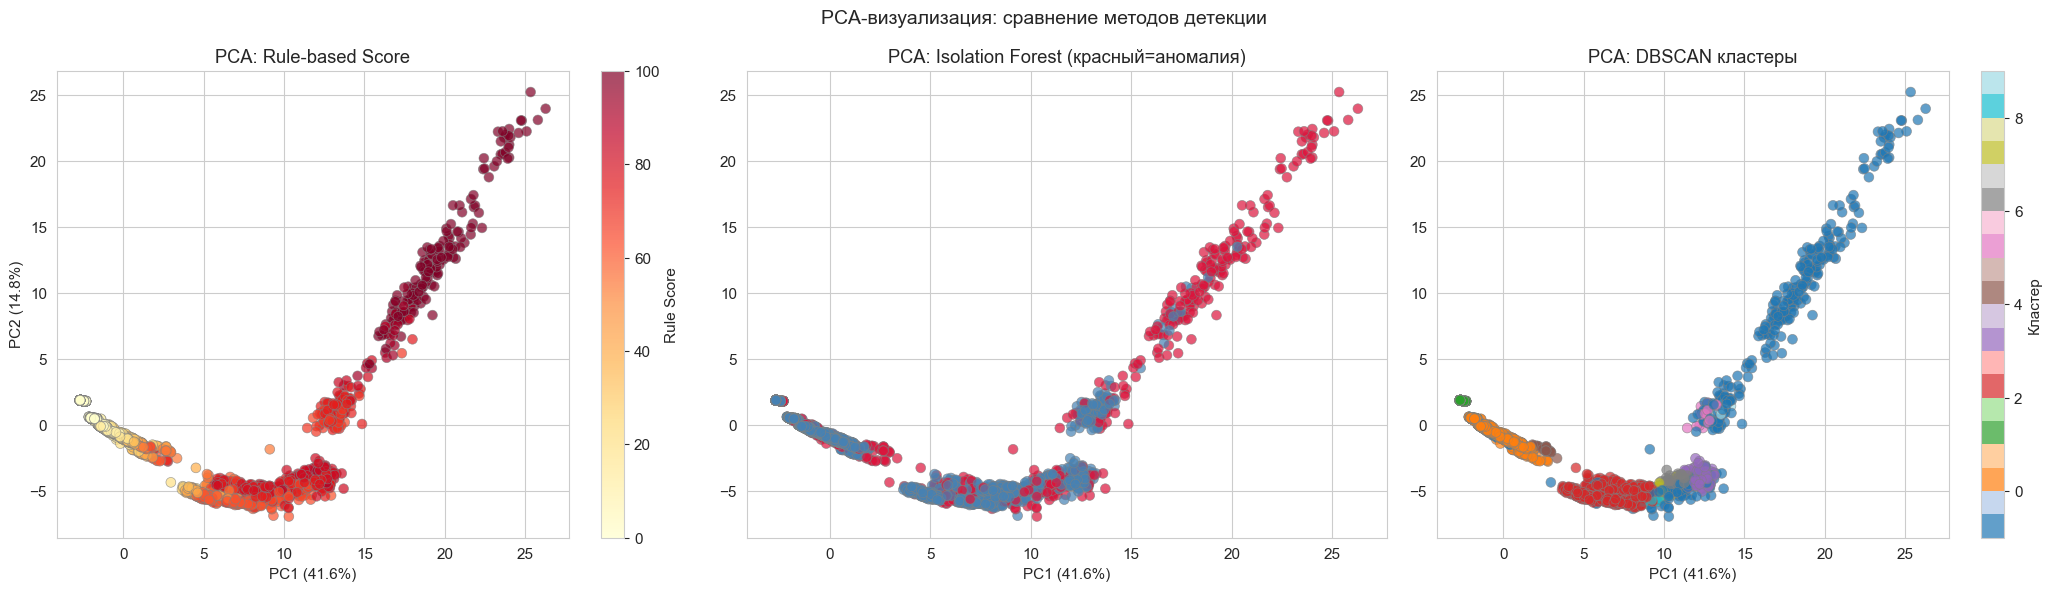


Объяснённая дисперсия PCA (2 компоненты): 56.4%


In [17]:
# ─── 5.5 PCA визуализация ───
pca = PCA(n_components=2, random_state=42)
X_pca2 = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 3, figsize=(21, 6))

# PCA: Rule-based score
scatter1 = axes[0].scatter(X_pca2[:, 0], X_pca2[:, 1],
                           c=df_company['rule_score'], cmap='YlOrRd',
                           alpha=0.7, s=50, edgecolors='grey', linewidths=0.5)
axes[0].set_title('PCA: Rule-based Score')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.colorbar(scatter1, ax=axes[0], label='Rule Score')

# PCA: Isolation Forest
colors_iso = ['crimson' if x == -1 else 'steelblue' for x in df_company['iso_score']]
axes[1].scatter(X_pca2[:, 0], X_pca2[:, 1], c=colors_iso, alpha=0.7, s=50,
                edgecolors='grey', linewidths=0.5)
axes[1].set_title('PCA: Isolation Forest (красный=аномалия)')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')

# PCA: DBSCAN
scatter3 = axes[2].scatter(X_pca2[:, 0], X_pca2[:, 1],
                           c=df_company['dbscan_cluster'], cmap='tab20',
                           alpha=0.7, s=50, edgecolors='grey', linewidths=0.5)
axes[2].set_title('PCA: DBSCAN кластеры')
axes[2].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.colorbar(scatter3, ax=axes[2], label='Кластер')

plt.suptitle('PCA-визуализация: сравнение методов детекции', fontsize=14)
plt.tight_layout()
plt.show()

print(f"\nОбъяснённая дисперсия PCA (2 компоненты): {pca.explained_variance_ratio_.sum():.1%}")

## 6. Composite Fraud Score — комбинированный скоринг

Объединяем результаты всех методов в единый скор:
- **Rule-based score** (40%) — экспертные правила
- **Isolation Forest score** (25%) — глобальные аномалии
- **LOF score** (20%) — локальные аномалии
- **DBSCAN noise flag** (15%) — кластерные выбросы

Распределение Composite Score (v3):
count   10000.00
mean       12.14
std        17.01
min         0.00
25%         1.20
50%         5.50
75%        13.10
max        90.00
Name: composite_score, dtype: float64

Confidence weighting:
  confidence_weight: mean=0.718, <1.0: 7,548 компаний
  Скор снижен (confidence<1): 6,186

Распределение по уровням риска:
  CRITICAL: 365 компаний (3.65%)
  HIGH: 871 компаний (8.71%)
  MEDIUM: 534 компаний (5.34%)
  LOW: 8,230 компаний (82.30%)


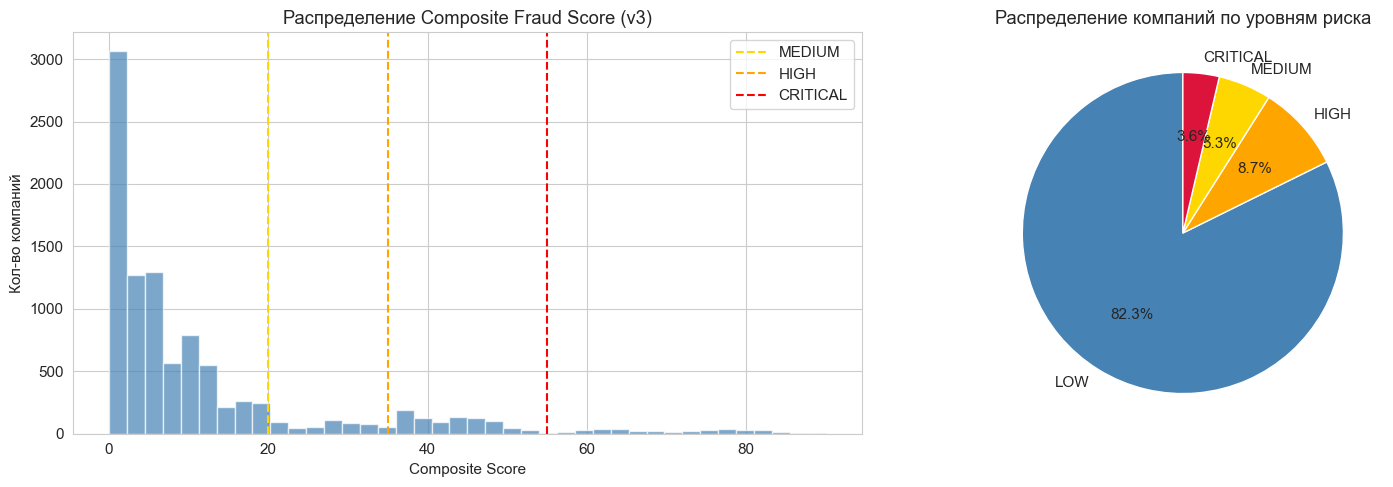

In [18]:
# ─── Composite Score (v3) ───
W_RULES  = 0.45
W_ISO    = 0.30
W_LOF    = 0.10
W_DBSCAN = 0.15

# DBSCAN: шум = 100, иначе 0
df_company['dbscan_noise_score'] = (df_company['dbscan_cluster'] == -1).astype(int) * 100

# Сырой composite (до confidence weighting)
df_company['composite_raw'] = (
    W_RULES  * df_company['rule_score'] +
    W_ISO    * df_company['iso_score_norm'] +
    W_LOF    * df_company['lof_score_norm'] +
    W_DBSCAN * df_company['dbscan_noise_score']
).round(1)

# Confidence weighting: понижаем скор компаний с малой полнотой данных
# data_completeness < 0.5 → линейное снижение, >= 0.5 → полный скор
df_company['confidence_weight'] = (df_company['data_completeness'] / 0.5).clip(upper=1.0)
df_company['composite_score'] = (df_company['composite_raw'] * df_company['confidence_weight']).round(1)

# Категоризация риска
def risk_category(score):
    if score >= 55:
        return 'CRITICAL'
    elif score >= 35:
        return 'HIGH'
    elif score >= 20:
        return 'MEDIUM'
    else:
        return 'LOW'

df_company['risk_level'] = df_company['composite_score'].apply(risk_category)

print("Распределение Composite Score (v3):")
print(df_company['composite_score'].describe())
print(f"\nConfidence weighting:")
print(f"  confidence_weight: mean={df_company['confidence_weight'].mean():.3f}, "
      f"<1.0: {(df_company['confidence_weight'] < 1.0).sum():,} компаний")
print(f"  Скор снижен (confidence<1): {(df_company['composite_raw'] != df_company['composite_score']).sum():,}")

print(f"\nРаспределение по уровням риска:")
risk_dist = df_company['risk_level'].value_counts()
for level in ['CRITICAL','HIGH','MEDIUM','LOW']:
    cnt = risk_dist.get(level, 0)
    pct = cnt / len(df_company) * 100
    print(f"  {level}: {cnt:,} компаний ({pct:.2f}%)")

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(df_company['composite_score'], bins=40, alpha=0.7, color='steelblue', edgecolor='white')
for thresh, color, label in [(20, 'gold', 'MEDIUM'), (35, 'orange', 'HIGH'), (55, 'red', 'CRITICAL')]:
    axes[0].axvline(x=thresh, color=color, linestyle='--', linewidth=1.5, label=label)
axes[0].set_xlabel('Composite Score')
axes[0].set_ylabel('Кол-во компаний')
axes[0].set_title('Распределение Composite Fraud Score (v3)')
axes[0].legend()

risk_counts = df_company['risk_level'].value_counts()
colors_pie = {'CRITICAL': 'crimson', 'HIGH': 'orange', 'MEDIUM': 'gold', 'LOW': 'steelblue'}
axes[1].pie(risk_counts, labels=risk_counts.index, autopct='%1.1f%%',
           colors=[colors_pie.get(x, 'grey') for x in risk_counts.index], startangle=90)
axes[1].set_title('Распределение компаний по уровням риска')
plt.tight_layout()
plt.show()

## 7. Feature Importance — важность признаков

Определяем, какие признаки вносят наибольший вклад в выявление аномалий (Isolation Forest).

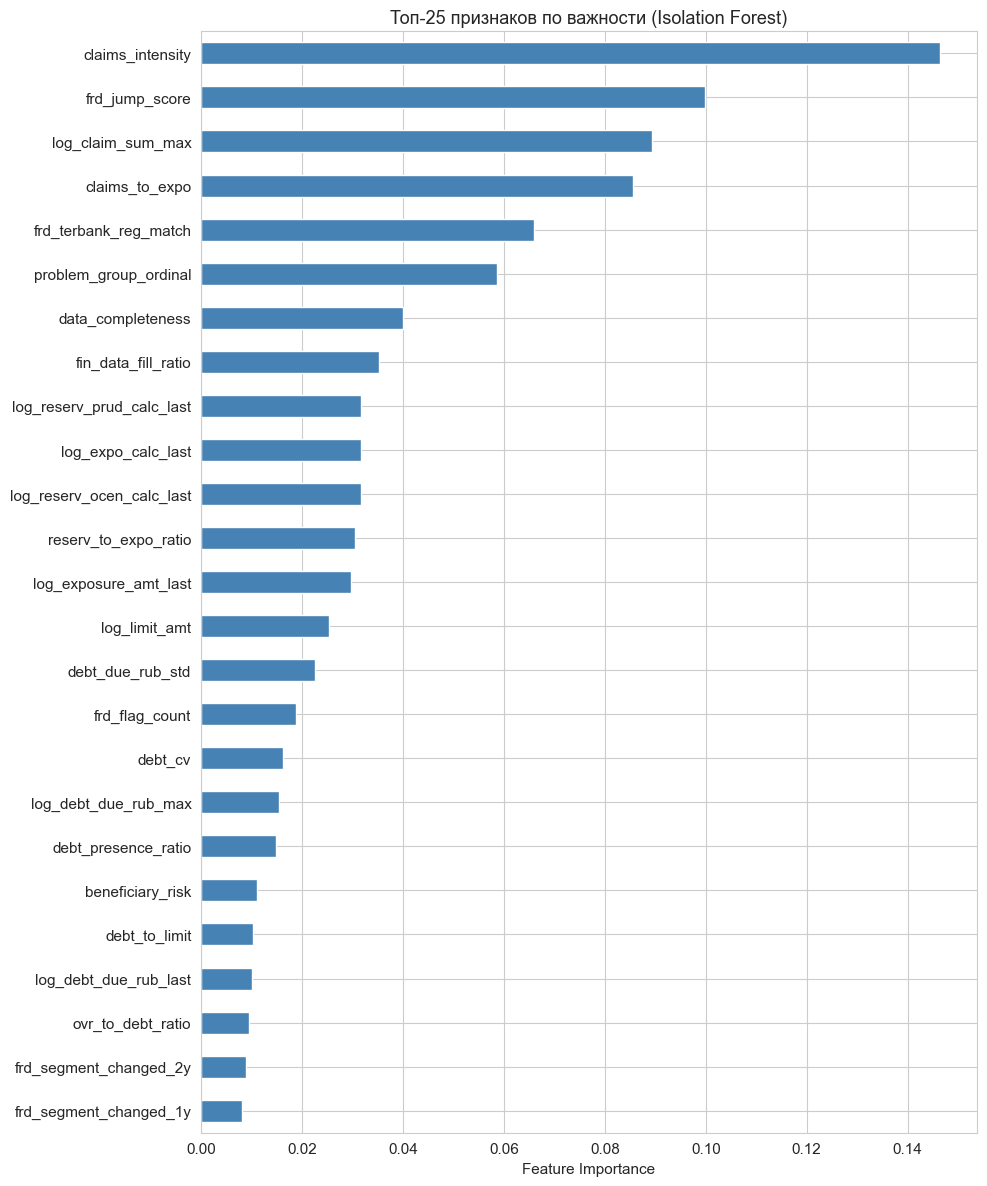

Топ-10 признаков:
  log_expo_calc_last: 0.0317
  log_reserv_prud_calc_last: 0.0318
  fin_data_fill_ratio: 0.0352
  data_completeness: 0.0399
  problem_group_ordinal: 0.0585
  frd_terbank_reg_match: 0.0659
  claims_to_expo: 0.0856
  log_claim_sum_max: 0.0892
  frd_jump_score: 0.0998
  claims_intensity: 0.1464


In [19]:
# ─── Feature Importance (на основе глубины деревьев Isolation Forest) ───
importances = pd.Series(
    iso_forest.feature_importances_ if hasattr(iso_forest, 'feature_importances_') 
    else np.mean([tree.feature_importances_ for tree in iso_forest.estimators_], axis=0),
    index=ml_features
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 12))
importances.tail(25).plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Топ-25 признаков по важности (Isolation Forest)', fontsize=13)
ax.set_xlabel('Feature Importance')
plt.tight_layout()
plt.show()

print("Топ-10 признаков:")
for feat, imp in importances.tail(10).items():
    print(f"  {feat}: {imp:.4f}")

## 8. Итоговый список подозрительных компаний

Финальная таблица с компаниями, отсортированными по composite fraud score, с техническим обоснованием фрода.

In [20]:
# ─── Формирование причин по ML-моделям ───
def build_ml_reasons(row):
    """Формирует техническое обоснование на основе ML-моделей."""
    parts = []
    if row['iso_score'] == -1:
        parts.append(f"ISO_FOREST_ANOMALY(score={row['iso_score_norm']:.0f})")
    if row['lof_pred'] == -1:
        parts.append(f"LOF_ANOMALY(score={row['lof_score_norm']:.0f})")
    if row['dbscan_cluster'] == -1:
        parts.append('DBSCAN_NOISE')
    return '|'.join(parts) if parts else ''

df_company['ml_reasons'] = df_company.apply(build_ml_reasons, axis=1)

# Объединяем все причины
df_company['all_reasons'] = df_company.apply(
    lambda r: '|'.join(filter(None, [r['rule_reasons'] if r['rule_reasons'] != 'CLEAN' else '',
                                      r['ml_reasons']])),
    axis=1
)

# ─── Итоговая таблица ───
suspicious = df_company[df_company['risk_level'].isin(['CRITICAL', 'HIGH', 'MEDIUM'])].sort_values(
    'composite_score', ascending=False
)

result_cols = [
    'inn', 'org_id', 'okved_section', 'org_sector', 'segment_name', 'reg_region',
    'terbank', 'risk_segment', 'liquidation', 'problem_group',
    'composite_score', 'confidence_weight', 'risk_level', 'rule_score',
    'iso_score_norm', 'lof_score_norm', 'dbscan_cluster',
    'debt_due_rub_last', 'debt_ovr_rub_max', 'exposure_amt_last',
    'restruct_cnt_max', 'ovr_cnt_max', 'had_default', 'in_default_now',
    'frd_jump_score', 'max_growth_pct',
    'had_claims', 'claim_sum_max', 'was_in_frd_registry',
    'all_reasons'
]

result_table = suspicious[result_cols].reset_index(drop=True)
result_table.index = result_table.index + 1
result_table.index.name = '#'

print(f"={'='*80}")
print(f"  ПОДОЗРИТЕЛЬНЫЕ КОМПАНИИ: {len(result_table)} из {len(df_company)}")
print(f"  CRITICAL: {(result_table['risk_level']=='CRITICAL').sum()}")
print(f"  HIGH: {(result_table['risk_level']=='HIGH').sum()}")
print(f"  MEDIUM: {(result_table['risk_level']=='MEDIUM').sum()}")
print(f"={'='*80}")

result_table

  ПОДОЗРИТЕЛЬНЫЕ КОМПАНИИ: 1770 из 10000
  CRITICAL: 365
  HIGH: 871
  MEDIUM: 534


,inn,org_id,okved_section,org_sector,segment_name,reg_region,terbank,risk_segment,liquidation,problem_group,composite_score,confidence_weight,risk_level,rule_score,iso_score_norm,lof_score_norm,dbscan_cluster,debt_due_rub_last,debt_ovr_rub_max,exposure_amt_last,restruct_cnt_max,ovr_cnt_max,had_default,in_default_now,frd_jump_score,max_growth_pct,had_claims,claim_sum_max,was_in_frd_registry,all_reasons
#,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,1000002267,1199000000003436846,G,Торговля,Малые,ленинградская область,Северо-Западный банк,Корп. компания-резидент (РФ),Действующее,Black Zone,90.00,1.00,CRITICAL,100,100.00,0.00,-1,65115203.90,87984543.50,128873750.92,4.00,47.00,1,1,0.87,880.23,1,5885416161.98,1,R1:REVENUE_JUMP>87%|R3:SEGMENT_CHANGED_1Y|R3:S...
2,1000000534,1199000000054276826,G,Торговля,Крупнейшие,смоленская область,Среднерусский банк,Корп. компания-резидент (РФ),Действующее,Black Zone,89.30,1.00,CRITICAL,100,97.70,0.00,-1,6011801212.98,5674317949.09,5729733475.94,4.00,46.00,1,1,0.76,1056.18,1,315127064.44,1,R1:REVENUE_JUMP>76%|R3:SEGMENT_CHANGED_1Y|R3:S...
3,1000008815,1199000000047521919,C,Промышленность,Рег. госсектор,нижегородская область,Юго-Западный банк,Кредитование корпоративных клиентов,Действующее,Black Zone,89.20,1.00,CRITICAL,100,97.50,0.00,-1,16368784200.22,26949753899.66,60975897295.06,1.00,47.00,1,1,0.89,859.77,1,116521235.94,1,R1:REVENUE_JUMP>89%|R2:TB_REG_MISMATCH|R3:SEGM...
4,1000002045,1199000000068428079,G,Торговля,Средние,ульяновская область,Поволжский банк,Корпоративная компания-резидент (РФ),Действующее,Black Zone,89.10,1.00,CRITICAL,100,97.00,0.00,-1,10856950916.57,4886714704.79,11503553560.60,4.00,46.00,1,1,0.94,493.82,1,224284825.79,1,R1:REVENUE_JUMP>94%|R3:SEGMENT_CHANGED_1Y|R3:S...
5,1000008713,1199000000002185644,O,Госсектор,Крупнейшие,томская область,Сибирский банк,Кредитование корпоративных клиентов,Действующее,Watchlist,88.30,1.00,CRITICAL,100,94.40,0.00,-1,4782745.13,2331142.22,29610780.74,4.00,45.00,1,1,0.85,578.92,1,1137667963.07,1,R1:REVENUE_JUMP>85%|R3:SEGMENT_CHANGED_1Y|R3:S...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1766,1000007026,1199000000030979128,G,Торговля,Средние,бурятия,Северо-Западный банк,Кредитование корпоративных клиентов,Действующее,Watchlist,20.00,1.00,MEDIUM,21,35.20,0.00,0,NaN,NaN,NaN,NaN,NaN,0,0,0.25,153.09,1,91682497.89,0,R2:TB_REG_MISMATCH|R3:SEGMENT_CHANGED_2Y|R12:H...
1767,1000004354,1199000000022030658,C,Промышленность,Крупные,калининградская область,Северо-Западный банк,Корпоративная компания-резидент (РФ),Действующее,Watchlist,20.00,1.00,MEDIUM,28,24.70,0.00,0,NaN,NaN,NaN,NaN,NaN,0,0,0.74,483.90,1,23605869.93,0,R1:REVENUE_JUMP>74%|R5:BENEFICIARY_CHANGED|R12...
1768,1000001973,1199000000035746366,H,Транспорт и логистика,Средние,ульяновская область,Уральский банк,Кредитование корпоративных клиентов,Действующее,NaN,20.00,0.89,MEDIUM,28,33.00,0.00,0,NaN,NaN,NaN,NaN,NaN,0,0,0.85,466.05,1,50617676.64,0,R1:REVENUE_JUMP>85%|R3:SEGMENT_CHANGED_2Y|R12:...


In [21]:
# ─── Детальная карта CRITICAL компаний ───
critical = result_table[result_table['risk_level'] == 'CRITICAL'].copy()

print(f"{'='*100}")
print(f"  ДЕТАЛИЗАЦИЯ CRITICAL-КОМПАНИЙ ({len(critical)} шт.)")
print(f"{'='*100}\n")

def fmt_rub(val):
    if pd.isna(val): return 'N/A'
    return f"{val:,.0f}"

for _, row in critical.head(30).iterrows():  # показываем первых 30
    print(f"--- INN: {row['inn']} | Org: {row['org_id']} | Score: {row['composite_score']} ---")
    print(f"    Отрасль: {row.get('org_sector','N/A')} | ОКВЭД: {row.get('okved_section','N/A')} | Сегмент: {row.get('segment_name','N/A')}")
    print(f"    Регион: {row.get('reg_region','N/A')} | ТБ: {row.get('terbank','N/A')} | Риск: {row.get('risk_segment','N/A')}")
    print(f"    Задолженность: {fmt_rub(row['debt_due_rub_last'])} руб | Макс.просрочка: {fmt_rub(row['debt_ovr_rub_max'])} руб")
    print(f"    Exposure: {fmt_rub(row['exposure_amt_last'])} руб | Реструктуризации: {row.get('restruct_cnt_max','N/A')}")
    js = row.get('frd_jump_score')
    gp = row.get('max_growth_pct')
    if pd.notna(js) and js > 0:
        print(f"    Взрывной рост: score={js:.2f}, рост={gp:.0f}%" if pd.notna(gp) else f"    Взрывной рост: score={js:.2f}")
    print(f"    ОБОСНОВАНИЕ: {row['all_reasons']}")
    print()

if len(critical) > 30:
    print(f"... и ещё {len(critical) - 30} CRITICAL-компаний (см. suspicious_companies.csv)")

  ДЕТАЛИЗАЦИЯ CRITICAL-КОМПАНИЙ (365 шт.)

--- INN: 1000002267 | Org: 1199000000003436846 | Score: 90.0 ---
    Отрасль: Торговля | ОКВЭД: G | Сегмент: Малые
    Регион: ленинградская область | ТБ: Северо-Западный банк | Риск: Корп. компания-резидент (РФ)
    Задолженность: 65,115,204 руб | Макс.просрочка: 87,984,543 руб
    Exposure: 128,873,751 руб | Реструктуризации: 4.0
    Взрывной рост: score=0.87, рост=880%
    ОБОСНОВАНИЕ: R1:REVENUE_JUMP>87%|R3:SEGMENT_CHANGED_1Y|R3:SEGMENT_CHANGED_2Y|R4:REJECT_DIFF_SEGMENT|R5:BENEFICIARY_CHANGED|R6:OWNER_CHANGED_1Y|R7:OKVED_DIFF_BEN0|R7:OKVED_DIFF_BEN1|R8:BEN0_LIQUIDATED|R8:BEN1_LIQUIDATED|R9:HIGH_OVERDUE_RATIO=78%|R10:RESTRUCT_CNT=4|R11:IN_DEFAULT_NOW|R12:HIGH_CLAIMS=5885M|R13:FRD_REGISTRY|R15:PROBLEM_GROUP=Black Zone|R16:HIGH_RESERV_RATIO=75.3%|R18:MULTI_FRD_FLAGS=5|R20:FRD_SUSP_FLAG|ISO_FOREST_ANOMALY(score=100)|DBSCAN_NOISE

--- INN: 1000000534 | Org: 1199000000054276826 | Score: 89.3 ---
    Отрасль: Торговля | ОКВЭД: G | Сегмент: Крупне

## 9. Углублённая аналитика

Расширенный анализ результатов:
- **9.1** Кросс-методная аналитика — согласование между методами детекции
- **9.2** Концентрация риска — по ТБ, ОКВЭД, сегментам
- **9.3** Статистическое профилирование — подозрительные vs чистые
- **9.4** Паттерны фрода — кластеризация подозрительных компаний
- **9.5** Сводная числовая статистика

  КРОСС-МЕТОДНАЯ АНАЛИТИКА: СОГЛАСОВАНИЕ МЕТОДОВ ДЕТЕКЦИИ

Количество компаний по числу сработавших методов:
  0      (CLEAN):    7,963 ( 79.63%)
  1    метод(ов):    1,478 ( 14.78%)
  2    метод(ов):      298 (  2.98%)
  3    метод(ов):      261 (  2.61%)
  4    метод(ов):        0 (  0.00%)

Матрица пересечений (кол-во компаний):
              Rules(≥40)   IsoForest         LOF      DBSCAN
  Rules(≥40)       1,519         384           0         366
  IsoForest          384         573          57         274
  LOF                  0          57         379           0
  DBSCAN             366         274           0         386

Высокая уверенность (3+ методов): 261 компаний
  Средний composite_score: 74.1
  Средний rule_score: 88.3

Максимальная уверенность (все 4 метода): 0 компаний


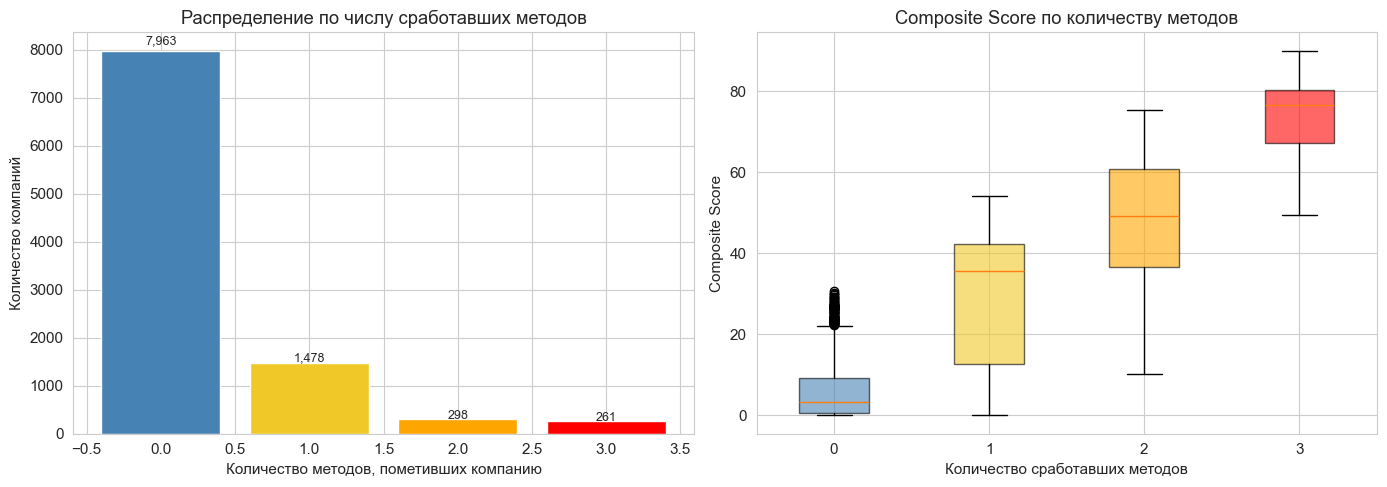

In [22]:
# ─── 9.1 Кросс-методная аналитика: согласование между методами ───

# Флаги детекции по каждому методу
df_company['det_rules'] = (df_company['rule_score'] >= 40).astype(int)
df_company['det_iso']   = (df_company['iso_score'] == -1).astype(int)
df_company['det_lof']   = (df_company['lof_pred'] == -1).astype(int)
df_company['det_dbscan'] = (df_company['dbscan_cluster'] == -1).astype(int)

df_company['n_methods_flagged'] = (
    df_company['det_rules'] + df_company['det_iso'] +
    df_company['det_lof'] + df_company['det_dbscan']
)

print("=" * 80)
print("  КРОСС-МЕТОДНАЯ АНАЛИТИКА: СОГЛАСОВАНИЕ МЕТОДОВ ДЕТЕКЦИИ")
print("=" * 80)

# Количество компаний по числу сработавших методов
print("\nКоличество компаний по числу сработавших методов:")
for n_m in range(5):
    cnt = (df_company['n_methods_flagged'] == n_m).sum()
    pct = cnt / len(df_company) * 100
    label = '(CLEAN)' if n_m == 0 else 'метод(ов)'
    print(f"  {n_m} {label:>12}: {cnt:>8,} ({pct:>6.2f}%)")

# Матрица пересечений
methods_dict = {'Rules(≥40)': 'det_rules', 'IsoForest': 'det_iso',
                'LOF': 'det_lof', 'DBSCAN': 'det_dbscan'}
print("\nМатрица пересечений (кол-во компаний):")
header = f"{'':14}" + "  ".join(f"{n:>10}" for n in methods_dict.keys())
print(header)
for m1_name, m1_col in methods_dict.items():
    row_vals = []
    for m2_name, m2_col in methods_dict.items():
        cnt = ((df_company[m1_col] == 1) & (df_company[m2_col] == 1)).sum()
        row_vals.append(f"{cnt:>10,}")
    print(f"  {m1_name:<12}" + "  ".join(row_vals))

# Высокая уверенность: 3+ метода
high_conf = df_company[df_company['n_methods_flagged'] >= 3]
print(f"\nВысокая уверенность (3+ методов): {len(high_conf):,} компаний")
if len(high_conf) > 0:
    print(f"  Средний composite_score: {high_conf['composite_score'].mean():.1f}")
    print(f"  Средний rule_score: {high_conf['rule_score'].mean():.1f}")

# Максимальная уверенность: все 4 метода
all_methods = df_company[df_company['n_methods_flagged'] == 4]
print(f"\nМаксимальная уверенность (все 4 метода): {len(all_methods):,} компаний")
if len(all_methods) > 0:
    print(f"  Средний composite_score: {all_methods['composite_score'].mean():.1f}")
    print(all_methods[['inn','org_id','composite_score','rule_score']].head(20).to_string(index=False))

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Барплот по числу методов
method_dist = df_company['n_methods_flagged'].value_counts().sort_index()
bar_colors = ['steelblue', '#f0c929', 'orange', 'red', 'darkred']
axes[0].bar(method_dist.index, method_dist.values,
            color=[bar_colors[i] for i in method_dist.index])
axes[0].set_xlabel('Количество методов, пометивших компанию')
axes[0].set_ylabel('Количество компаний')
axes[0].set_title('Распределение по числу сработавших методов')
for x, v in zip(method_dist.index, method_dist.values):
    axes[0].text(x, v + v*0.02, f'{v:,}', ha='center', fontsize=9)

# Composite Score по количеству методов (boxplot вручную)
data_by_methods = [df_company[df_company['n_methods_flagged'] == i]['composite_score'].values
                   for i in sorted(df_company['n_methods_flagged'].unique())]
bp = axes[1].boxplot(data_by_methods,
                     labels=sorted(df_company['n_methods_flagged'].unique()),
                     patch_artist=True)
for patch, color in zip(bp['boxes'], bar_colors[:len(bp['boxes'])]):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[1].set_xlabel('Количество сработавших методов')
axes[1].set_ylabel('Composite Score')
axes[1].set_title('Composite Score по количеству методов')
plt.tight_layout()
plt.show()

  КОНЦЕНТРАЦИЯ РИСКА ПО СРЕЗАМ

Топ-15 ТБ по доле подозрительных компаний (CRITICAL+HIGH):
                             total  suspicious  mean_score  max_score  susp_pct
terbank                                                                        
Центральный аппарат            119          17       12.80      84.40     14.29
Уральский банк                 870         115       12.50      85.20     13.22
Среднерусский банк            1128         149       12.40      89.30     13.21
Байкальский банк               303          40       12.90      81.40     13.20
Юго-Западный банк             1169         152       12.30      89.20     13.00
Поволжский банк                679          85       12.50      89.10     12.52
Северо-Западный банк          1398         172       12.20      90.00     12.30
Волго-Вятский банк             925         113       11.90      84.80     12.22
Сибирский банк                 723          85       12.20      88.30     11.76
Центрально-Черноземный банк  

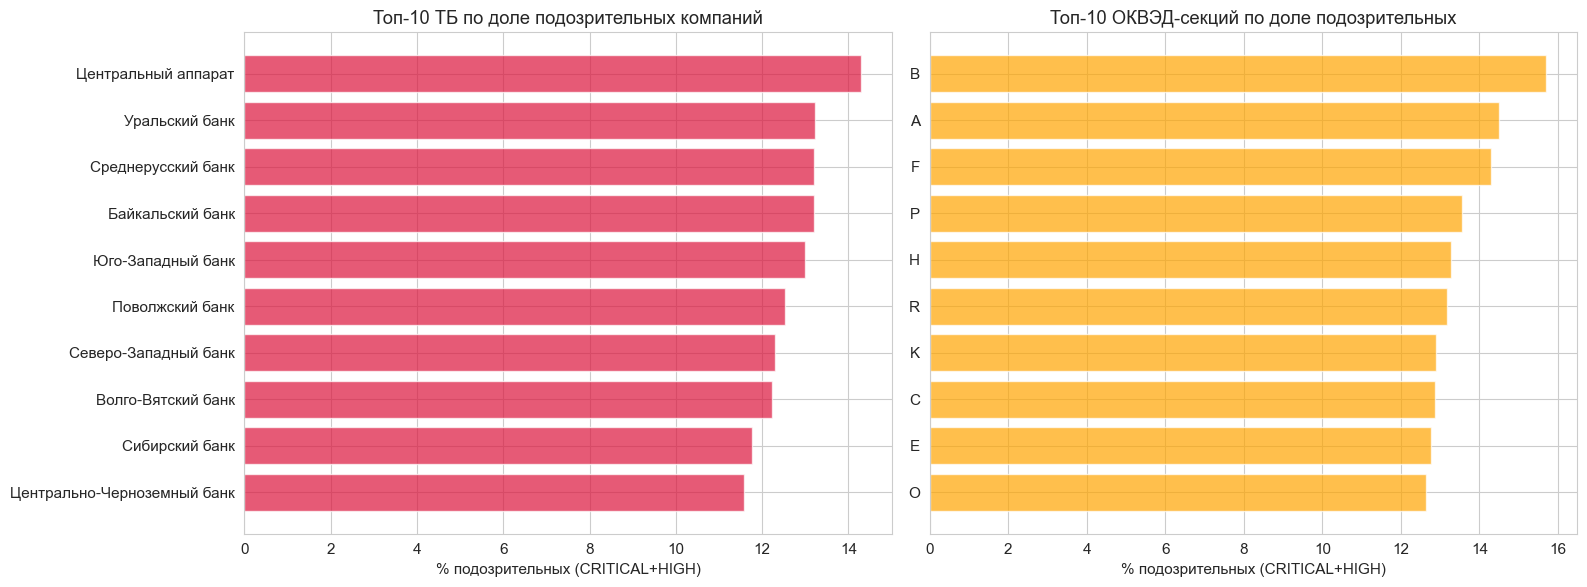

In [23]:
# ─── 9.2 Концентрация риска: ТБ, ОКВЭД, сегменты ───

print("=" * 80)
print("  КОНЦЕНТРАЦИЯ РИСКА ПО СРЕЗАМ")
print("=" * 80)

# По ТБ
if 'terbank' in df_company.columns and df_company['terbank'].notna().sum() > 0:
    tb_stats = df_company.groupby('terbank').agg(
        total=('inn', 'count'),
        suspicious=('risk_level', lambda x: x.isin(['CRITICAL','HIGH']).sum()),
        mean_score=('composite_score', 'mean'),
        max_score=('composite_score', 'max')
    ).round(1)
    tb_stats['susp_pct'] = (tb_stats['suspicious'] / tb_stats['total'] * 100).round(2)
    tb_stats = tb_stats.sort_values('susp_pct', ascending=False)
    print(f"\nТоп-15 ТБ по доле подозрительных компаний (CRITICAL+HIGH):")
    print(tb_stats.head(15).to_string())
else:
    tb_stats = pd.DataFrame()

# По ОКВЭД
if 'okved_section' in df_company.columns and df_company['okved_section'].notna().sum() > 0:
    okved_stats = df_company.groupby('okved_section').agg(
        total=('inn', 'count'),
        suspicious=('risk_level', lambda x: x.isin(['CRITICAL','HIGH']).sum()),
        mean_score=('composite_score', 'mean'),
        max_score=('composite_score', 'max')
    ).round(1)
    okved_stats['susp_pct'] = (okved_stats['suspicious'] / okved_stats['total'] * 100).round(2)
    okved_stats = okved_stats.sort_values('susp_pct', ascending=False)
    print(f"\nТоп-15 ОКВЭД-секций по доле подозрительных:")
    print(okved_stats.head(15).to_string())
else:
    okved_stats = pd.DataFrame()

# По сегменту
if 'segment_name' in df_company.columns and df_company['segment_name'].notna().sum() > 0:
    seg_stats = df_company.groupby('segment_name').agg(
        total=('inn', 'count'),
        suspicious=('risk_level', lambda x: x.isin(['CRITICAL','HIGH']).sum()),
        mean_score=('composite_score', 'mean')
    ).round(1)
    seg_stats['susp_pct'] = (seg_stats['suspicious'] / seg_stats['total'] * 100).round(2)
    seg_stats = seg_stats.sort_values('susp_pct', ascending=False)
    print(f"\nПо сегменту клиента:")
    print(seg_stats.to_string())

# По проблемной группе
if 'problem_group' in df_company.columns and df_company['problem_group'].notna().sum() > 0:
    pg_stats = df_company.groupby('problem_group').agg(
        total=('inn', 'count'),
        suspicious=('risk_level', lambda x: x.isin(['CRITICAL','HIGH']).sum()),
        mean_score=('composite_score', 'mean')
    ).round(1)
    pg_stats['susp_pct'] = (pg_stats['suspicious'] / pg_stats['total'] * 100).round(2)
    pg_stats = pg_stats.sort_values('susp_pct', ascending=False)
    print(f"\nПо проблемной группе:")
    print(pg_stats.to_string())

# Визуализации
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

if len(tb_stats) > 0:
    top_tb = tb_stats.head(10)
    axes[0].barh(top_tb.index.astype(str), top_tb['susp_pct'], color='crimson', alpha=0.7)
    axes[0].set_xlabel('% подозрительных (CRITICAL+HIGH)')
    axes[0].set_title('Топ-10 ТБ по доле подозрительных компаний')
    axes[0].invert_yaxis()

if len(okved_stats) > 0:
    top_okved = okved_stats.head(10)
    axes[1].barh(top_okved.index.astype(str), top_okved['susp_pct'], color='orange', alpha=0.7)
    axes[1].set_xlabel('% подозрительных (CRITICAL+HIGH)')
    axes[1].set_title('Топ-10 ОКВЭД-секций по доле подозрительных')
    axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

  СТАТИСТИЧЕСКОЕ ПРОФИЛИРОВАНИЕ: ПОДОЗРИТЕЛЬНЫЕ vs ЧИСТЫЕ

Сравнение CRITICAL+HIGH (1,236) vs LOW (8,230):
(Mann-Whitney U тест: *** p<0.001, ** p<0.01, * p<0.05)

  debt_due_rub_last            Flagged: 424,093,805.42  |  Clean:           0.00  |  Ratio:     N/A  n/a
  debt_ovr_rub_max             Flagged: 176,940,536.50  |  Clean:           0.00  |  Ratio:     N/A  n/a
  exposure_amt_last            Flagged: 2,232,698,187.72  |  Clean:           0.00  |  Ratio:     N/A  n/a
  limit_amt                    Flagged: 3,880,089,673.70  |  Clean:           0.00  |  Ratio:     N/A  n/a
  debt_growth_ratio            Flagged:           0.00  |  Clean:           0.00  |  Ratio:     N/A  n/a
  overdue_month_ratio          Flagged:           0.11  |  Clean:           0.00  |  Ratio:     N/A  ***
  debt_cv                      Flagged:           0.33  |  Clean:           0.00  |  Ratio:     N/A  n/a
  restruct_cnt_max             Flagged:           1.33  |  Clean:           0.00  |  Ratio:     N

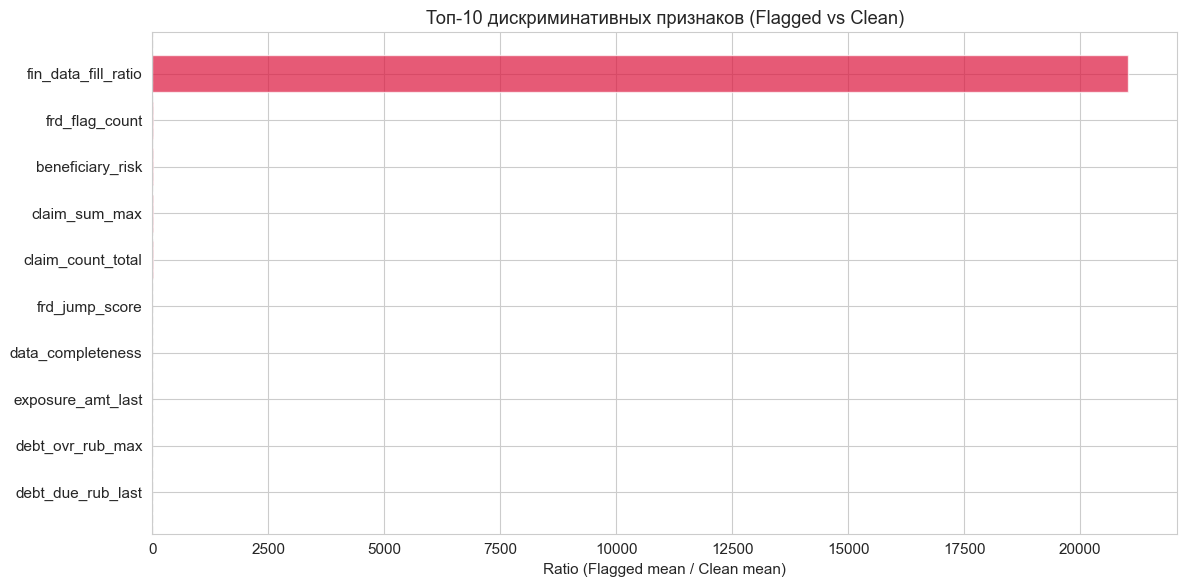

In [24]:
# ─── 9.3 Статистическое профилирование: подозрительные vs чистые ───

print("=" * 80)
print("  СТАТИСТИЧЕСКОЕ ПРОФИЛИРОВАНИЕ: ПОДОЗРИТЕЛЬНЫЕ vs ЧИСТЫЕ")
print("=" * 80)

flagged = df_company[df_company['risk_level'].isin(['CRITICAL', 'HIGH'])]
clean = df_company[df_company['risk_level'] == 'LOW']

compare_cols = [
    'debt_due_rub_last', 'debt_ovr_rub_max', 'exposure_amt_last', 'limit_amt',
    'debt_growth_ratio', 'overdue_month_ratio', 'debt_cv',
    'restruct_cnt_max', 'ovr_cnt_max', 'claim_sum_max', 'claim_count_total',
    'frd_jump_score', 'frd_flag_count', 'beneficiary_risk',
    'data_completeness', 'overdue_severity', 'fin_data_fill_ratio',
    'debt_trend_slope', 'debt_presence_ratio'
]
compare_cols = [c for c in compare_cols if c in df_company.columns]

rows = []
for col in compare_cols:
    f_vals = flagged[col].dropna()
    c_vals = clean[col].dropna()

    c_mean = c_vals.mean() if len(c_vals) > 0 else 0
    f_mean = f_vals.mean() if len(f_vals) > 0 else 0
    row = {
        'Признак': col,
        'Flagged_N': len(f_vals),
        'Flagged_mean': f_mean,
        'Flagged_median': f_vals.median() if len(f_vals) > 0 else np.nan,
        'Clean_N': len(c_vals),
        'Clean_mean': c_mean,
        'Clean_median': c_vals.median() if len(c_vals) > 0 else np.nan,
        'Ratio_mean': f_mean / c_mean if c_mean != 0 else np.nan
    }

    # Mann-Whitney U test
    if len(f_vals) > 30 and len(c_vals) > 30:
        stat, pval = mannwhitneyu(f_vals, c_vals, alternative='two-sided')
        row['p_value'] = pval
        row['Significant'] = '***' if pval < 0.001 else ('**' if pval < 0.01 else ('*' if pval < 0.05 else ''))
    else:
        row['p_value'] = np.nan
        row['Significant'] = 'n/a'

    rows.append(row)

profile_df = pd.DataFrame(rows)
print(f"\nСравнение CRITICAL+HIGH ({len(flagged):,}) vs LOW ({len(clean):,}):")
print(f"(Mann-Whitney U тест: *** p<0.001, ** p<0.01, * p<0.05)\n")

for _, r in profile_df.iterrows():
    rr = r['Ratio_mean']
    sig = r['Significant']
    f_str = f"{r['Flagged_mean']:>14,.2f}" if pd.notna(r['Flagged_mean']) else f"{'N/A':>14}"
    c_str = f"{r['Clean_mean']:>14,.2f}" if pd.notna(r['Clean_mean']) else f"{'N/A':>14}"
    r_str = f"{rr:>6.2f}x" if pd.notna(rr) else f"{'N/A':>7}"
    print(f"  {r['Признак']:<28} Flagged: {f_str}  |  Clean: {c_str}  |  Ratio: {r_str}  {sig}")

# Топ дискриминативных признаков
profile_df['abs_ratio'] = profile_df['Ratio_mean'].apply(lambda x: abs(x - 1) if pd.notna(x) else 0)
top_disc = profile_df.nlargest(10, 'abs_ratio')
print(f"\nТоп-10 наиболее дискриминативных признаков:")
for _, r in top_disc.iterrows():
    rr = r['Ratio_mean']
    print(f"  {r['Признак']:<28}: ratio={rr:.2f}x  {r['Significant']}" if pd.notna(rr) else f"  {r['Признак']:<28}: N/A")

# Визуализация топ-10 по ratio
fig, ax = plt.subplots(figsize=(12, 6))
top_disc_plot = top_disc.sort_values('abs_ratio')
colors = ['crimson' if r > 1 else 'steelblue' for r in top_disc_plot['Ratio_mean'].fillna(1)]
ax.barh(top_disc_plot['Признак'], top_disc_plot['Ratio_mean'].fillna(1), color=colors, alpha=0.7)
ax.axvline(x=1, color='black', linestyle='--', alpha=0.5)
ax.set_xlabel('Ratio (Flagged mean / Clean mean)')
ax.set_title('Топ-10 дискриминативных признаков (Flagged vs Clean)')
plt.tight_layout()
plt.show()

  ПАТТЕРНЫ ФРОДА: ТИПОЛОГИЯ ПОДОЗРИТЕЛЬНЫХ КОМПАНИЙ

Выявлено 3 паттернов фрода среди 1,770 подозрительных компаний:

─── Паттерн 0 (374 компаний) ───
  Уровни риска: HIGH: 201, CRITICAL: 173
  rule_score                  : mean=       75.32  med=       76.00
  composite_score             : mean=       55.15  med=       52.70
  debt_due_rub_last           : mean=429,075,157.67  med=        0.00
  debt_ovr_rub_max            : mean=15,529,869.38  med=        0.00
  frd_jump_score              : mean=        0.85  med=        0.87
  overdue_month_ratio         : mean=        0.04  med=        0.00
  restruct_cnt_max            : mean=        0.93  med=        1.00
  claim_sum_max               : mean=2,203,817,849.87  med=369,743,883.34
  frd_flag_count              : mean=        3.00  med=        3.00
  beneficiary_risk            : mean=        0.71  med=        0.75
  data_completeness           : mean=        0.99  med=        1.00
  overdue_severity            : mean=        0.01  

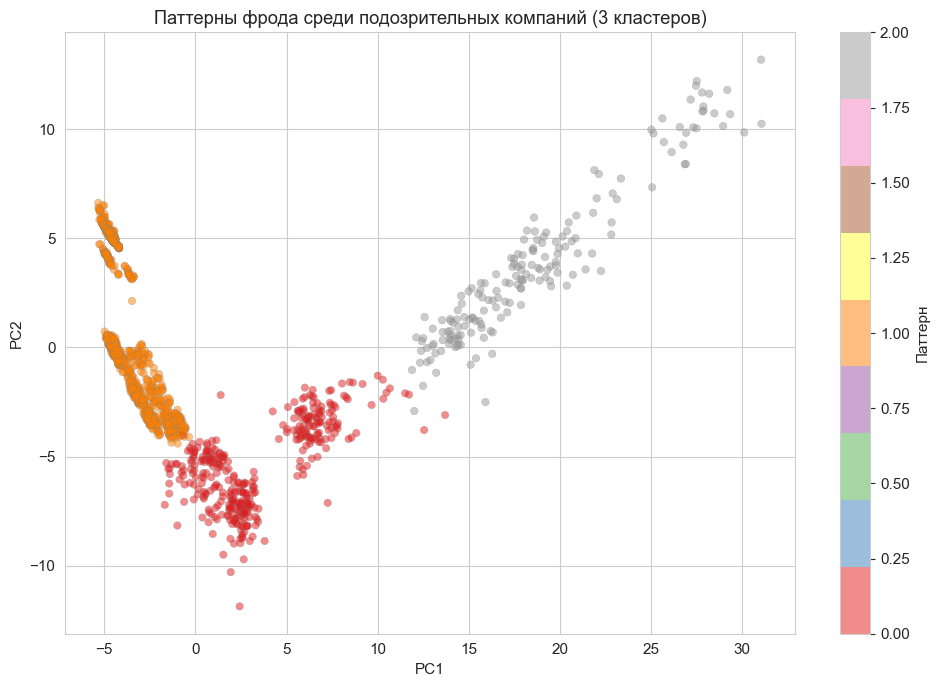

In [25]:
# ─── 9.4 Паттерны фрода: кластеризация подозрительных компаний ───

print("=" * 80)
print("  ПАТТЕРНЫ ФРОДА: ТИПОЛОГИЯ ПОДОЗРИТЕЛЬНЫХ КОМПАНИЙ")
print("=" * 80)

# Кластеризация подозрительных для выявления типов фрода
suspicious_idx = df_company['risk_level'].isin(['CRITICAL', 'HIGH', 'MEDIUM'])
if suspicious_idx.sum() >= 100:

    X_susp = X_scaled_df.loc[suspicious_idx].values

    # Подбираем число кластеров (от 3 до 8)
    n_fraud_clusters = min(6, max(3, suspicious_idx.sum() // 1000))
    kmeans_fraud = KMeans(n_clusters=n_fraud_clusters, random_state=42, n_init=10)
    fraud_labels = kmeans_fraud.fit_predict(X_susp)
    df_company.loc[suspicious_idx, 'fraud_pattern'] = fraud_labels

    susp_df = df_company[suspicious_idx].copy()
    print(f"\nВыявлено {n_fraud_clusters} паттернов фрода среди {suspicious_idx.sum():,} подозрительных компаний:\n")

    profile_features = ['rule_score', 'composite_score', 'debt_due_rub_last',
                        'debt_ovr_rub_max', 'frd_jump_score', 'overdue_month_ratio',
                        'restruct_cnt_max', 'claim_sum_max', 'frd_flag_count',
                        'beneficiary_risk', 'data_completeness', 'overdue_severity']
    profile_features = [f for f in profile_features if f in susp_df.columns]

    for pat in range(n_fraud_clusters):
        mask = susp_df['fraud_pattern'] == pat
        pat_df = susp_df[mask]
        print(f"─── Паттерн {pat} ({len(pat_df):,} компаний) ───")

        # Распределение по уровням риска
        rl = pat_df['risk_level'].value_counts()
        rl_str = ', '.join(f"{lev}: {cnt}" for lev, cnt in rl.items())
        print(f"  Уровни риска: {rl_str}")

        # Ключевые статистики
        for feat in profile_features:
            vals = pat_df[feat].dropna()
            if len(vals) > 0:
                print(f"  {feat:<28}: mean={vals.mean():>12,.2f}  med={vals.median():>12,.2f}")

        # Топ правил в паттерне
        rules_in_pat = []
        for reasons in pat_df['rule_reasons']:
            if reasons and str(reasons) != 'CLEAN' and str(reasons) != 'nan':
                for r in str(reasons).split('|'):
                    if ':' in r:
                        parts = r.split(':')
                        code = parts[0] + ':' + parts[1].split('=')[0].split('>')[0]
                    else:
                        code = r
                    rules_in_pat.append(code)
        if rules_in_pat:
            top5 = Counter(rules_in_pat).most_common(5)
            print(f"  Топ-5 правил: {', '.join(f'{r}({c})' for r, c in top5)}")
        print()

    # PCA визуализация паттернов
    pca_susp = PCA(n_components=2, random_state=42).fit_transform(X_susp)
    fig, ax = plt.subplots(figsize=(10, 7))
    scatter = ax.scatter(pca_susp[:, 0], pca_susp[:, 1],
                         c=fraud_labels, cmap='Set1', alpha=0.5, s=30, edgecolors='grey', linewidths=0.3)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_title(f'Паттерны фрода среди подозрительных компаний ({n_fraud_clusters} кластеров)')
    plt.colorbar(scatter, label='Паттерн')
    plt.tight_layout()
    plt.show()
else:
    print("Недостаточно подозрительных компаний для кластеризации паттернов.")

In [26]:
# ─── [ТЕСТ] Оценка качества моделей (только при наличии ground truth) ───
# Эта ячейка работает только с тестовыми данными, где известны истинные метки.
test_gt_path = RAW_DATA_DIR / 'test_gt.csv'
_gt_available = False

if not test_gt_path.exists():
    legacy_dirs = [Path.cwd(), PROJECT_ROOT / 'notebooks', PROJECT_ROOT]
    legacy_candidates = [legacy_dir / 'test_gt.csv' for legacy_dir in legacy_dirs]
    for legacy_path in legacy_candidates:
        if legacy_path.exists() and legacy_path.resolve() != test_gt_path.resolve():
            legacy_path.replace(test_gt_path)
            break

if test_gt_path.exists():
    _gt = pd.read_csv(test_gt_path, sep=';')
    _gt_map = dict(zip(_gt['inn'].astype(str), _gt['_is_fraud']))
    df_company['_is_fraud'] = df_company['inn'].astype(str).map(_gt_map).fillna(0).astype(int)
    _gt_available = True

if _gt_available and df_company['_is_fraud'].sum() > 0:
    from sklearn.metrics import precision_score, recall_score, f1_score

    print("=" * 70)
    print("  [ТЕСТ] МЕТРИКИ КАЧЕСТВА МОДЕЛЕЙ (vs Ground Truth)")
    print("=" * 70)

    y_true = df_company['_is_fraud'].values
    methods = {
        'Rule-based (score>=40)': (df_company['rule_score'] >= 40).astype(int).values,
        'Isolation Forest': (df_company['iso_score'] == -1).astype(int).values,
        'LOF': (df_company['lof_pred'] == -1).astype(int).values,
        'DBSCAN (noise)': (df_company['dbscan_cluster'] == -1).astype(int).values,
        'Composite (>=35)': (df_company['composite_score'] >= 35).astype(int).values,
        'Composite (>=20)': (df_company['composite_score'] >= 20).astype(int).values,
    }

    metrics_rows = []
    for name, y_pred in methods.items():
        p = precision_score(y_true, y_pred, zero_division=0)
        r = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        detected = y_pred.sum()
        true_pos = ((y_pred == 1) & (y_true == 1)).sum()
        metrics_rows.append({
            'Метод': name, 'Detected': detected, 'True Positives': true_pos,
            'Precision': f'{p:.1%}', 'Recall': f'{r:.1%}', 'F1': f'{f1:.1%}'
        })

    metrics_df = pd.DataFrame(metrics_rows)
    print(metrics_df.to_string(index=False))
    
    # Убираем тестовый столбец
    df_company.drop(columns=['_is_fraud'], inplace=True, errors='ignore')
else:
    print(f"Ground truth ({test_gt_path}) не найден — пропускаем оценку качества.")
    print("Это нормально при работе с реальными данными.")

  [ТЕСТ] МЕТРИКИ КАЧЕСТВА МОДЕЛЕЙ (vs Ground Truth)
                 Метод  Detected  True Positives Precision Recall    F1
Rule-based (score>=40)      1519             775     51.0% 100.0% 67.6%
      Isolation Forest       573             293     51.1%  37.8% 43.5%
                   LOF       379               0      0.0%   0.0%  0.0%
        DBSCAN (noise)       386             353     91.5%  45.5% 60.8%
      Composite (>=35)      1236             775     62.7% 100.0% 77.1%
      Composite (>=20)      1770             775     43.8% 100.0% 60.9%


In [27]:
# ─── Экспорт результатов ───
export_cols = ['inn','org_id','okved_section','org_sector','segment_name','reg_region',
               'terbank','risk_segment','liquidation','problem_group',
               'composite_score','risk_level','rule_score',
               'iso_score_norm','lof_score_norm','dbscan_cluster',
               'n_methods_flagged',
               'debt_due_rub_last','debt_ovr_rub_max','exposure_amt_last','limit_amt',
               'restruct_cnt_max','ovr_cnt_max','had_default','in_default_now',
               'frd_jump_score','max_growth_pct','had_claims','claim_sum_max',
               'was_in_frd_registry','frd_confirmed',
               'data_completeness','beneficiary_risk','overdue_severity',
               'frd_flag_count','debt_trend_slope',
               'all_reasons']
export_cols = [c for c in export_cols if c in df_company.columns]

fraud_scores_path = PROCESSED_DATA_DIR / 'fraud_scores_all.csv'
suspicious_path = PROCESSED_DATA_DIR / 'suspicious_companies.csv'

# Все компании с скоринговыми метками
df_company[export_cols].sort_values('composite_score', ascending=False).to_csv(
    fraud_scores_path, index=False, sep=';'
 )
# Только подозрительные
result_cols_export = [c for c in result_cols if c in suspicious.columns]
suspicious[result_cols_export].to_csv(suspicious_path, index=False, sep=';')

print("Экспортировано:")
print(f"  {fraud_scores_path} — все {len(df_company):,} компании с фрод-скором")
print(f"  {suspicious_path} — {len(suspicious):,} подозрительных компаний")
print(f"\nАналитика завершена.")

Экспортировано:
  C:\Users\Egor\Desktop\hseml-group-project-gorg1t\data\processed\fraud_scores_all.csv — все 10,000 компании с фрод-скором
  C:\Users\Egor\Desktop\hseml-group-project-gorg1t\data\processed\suspicious_companies.csv — 1,770 подозрительных компаний

Аналитика завершена.
